# Workflow di diagnosi data-driven (5 Tappe):
1. Acquisizione dati
2. Preprocessamento
3. Estrazione feature
## 4. **Addestramento**
5. Integrazione


**Ambito di questo notebook: Tappa 4 (Addestramento) — regressione.**
Copre gli step tecnici 4.1 (Algorithm Selection) -> 4.2 (Model Training/CV) -> 4.4
(Model Evaluation/Ranking)

> Le celle di codice sottostanti non vengono modificate nella loro logica di lettura JSON/Parquet/pkl. Le celle Markdown aggiunte mappano ogni blocco al passo del workflow corrispondente e includono una breve legenda dei termini mostrati nei grafici.

In [1]:
import sys
sys.path.append("../../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib  # Libreria standard per la deserializzazione dei modelli ML
from scipy.stats import norm
import json
import ast
import pandas as pd
import joblib
import pickle
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

from IPython.display import display, Markdown # Importante per renderizzare l'analisi


In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase4_data_modeling"

## 4. Addestramento — Selezione dell'Algoritmo

Configurazione architetturale del modello scelto per la regressione probabilistica del margine di coppia.

In [3]:
# --------------- SELEZIONE DEI DATI - step_4_1_algorithm_selection

Cosa fa davvero NGBoost:

Il modello non produce un solo numero per trq_margin, ma una distribuzione gaussiana completa: media (μ) e deviazione standard (σ). Per ottenere questo, NGBoost addestra due ensemble di alberi in parallelo, uno per μ e uno per σ, entrambi ottimizzati con la stessa LogScore (Negative Log-Likelihood) sotto distribuzione Normal. Il ramo σ è deliberatamente più semplice (meno alberi, alberi meno profondi, foglie con più campioni minimi) — pratica standard per evitare che la stima dell'incertezza diventi instabile o rumorosa.

In [4]:
# 4.1.modeling.algo_setup_trace.json

**Termini nel grafico:**
- **NGBoost**: algoritmo di boosting che predice un'intera distribuzione di probabilità (non solo un valore puntuale), qui configurato con distribuzione Normale (media μ + deviazione standard σ).
- **Base Learner (Weak Learner)**: gli alberi decisionali semplici che compongono l'ensemble; qui limitati in profondità (`max_depth`) per evitare overfitting.
- **`n_estimators`**: numero di alberi sequenziali nell'ensemble.



4.1.modeling.algo_setup_trace.json non è la configurazione finale del modello — è il punto di partenza dichiarato prima della ricerca di iperparametri. È importante non presentarlo al professore come "la" configurazione, perché non lo è.

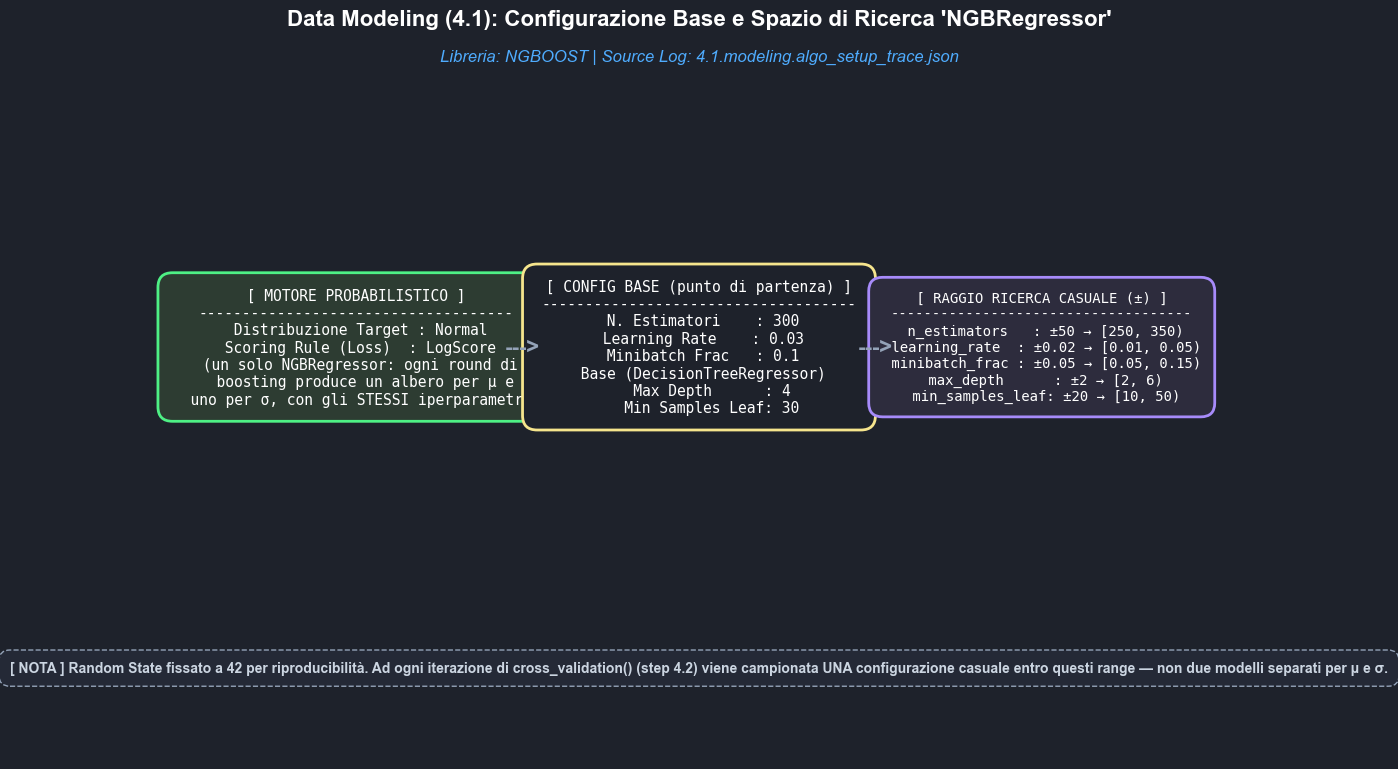


 ANALISI CONCLUSIVA: CONFIGURAZIONE ALGORITMO E SPAZIO DI RICERCA (4.1)
La scelta architetturale è ricaduta su 'NGBRegressor' della libreria 'ngboost'.
Questo artefatto è stato prodotto da 'single_probabilistic_architecture()'
in regression_algorithm_selector_model.py — confermato dalla presenza dei
campi '_uncertainty' a livello superiore, assenti nell'implementazione
alternativa trovata in regression_trainer_model.py (funzione morta/non
eseguita per questo step).

1. NATURA PROBABILISTICA:
   NGBoost addestra UN SOLO ensemble sotto la distribuzione 'Normal':
   ad ogni round di boosting vengono generati alberi che approssimano il
   gradiente naturale sia per μ (media) sia per σ (incertezza), condividendo
   gli stessi iperparametri di round.

2. CAMPI '_uncertainty':
   Rappresentano il raggio (±) del campionamento casuale usato dalla ricerca
   di iperparametri in step 4.2 — non un secondo modello. Il valore
   effettivamente selezionato da quella ricerca (best_config) e la verifi

In [6]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_setup = "4.1.modeling.algo_setup_trace.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
libreria = setup_data.get("library", "N/D")
stimatore = setup_data.get("estimator", "N/D")
config = setup_data.get("model_configured", {})

distribuzione = config.get("Dist", "N/D")
funzione_score = config.get("Score", "N/D")

num_estimatori = config.get("n_estimators", "N/D")
learning_rate = config.get("learning_rate", "N/D")
minibatch_frac = config.get("minibatch_frac", "N/D")

raggio_n_estimatori = config.get("n_estimators_uncertainty", "N/D")
raggio_learning_rate = config.get("learning_rate_uncertainty", "N/D")
raggio_minibatch_frac = config.get("minibatch_frac_uncertainty", "N/D")

base_learner = config.get("Base", {})
tipo_base = base_learner.get("type", "N/D")
profondita_max = base_learner.get("max_depth", "N/D")
foglie_minime = base_learner.get("min_samples_leaf", "N/D")

raggio_profondita_max = base_learner.get("max_depth_uncertainty", "N/D")
raggio_foglie_minime = base_learner.get("min_samples_leaf_uncertainty", "N/D")

def _range_str(base, raggio):
    if isinstance(base, (int, float)) and isinstance(raggio, (int, float)):
        return f"[{base - raggio:.4g}, {base + raggio:.4g})"
    return "N/D"

range_n_estimatori = _range_str(num_estimatori, raggio_n_estimatori)
range_learning_rate = _range_str(learning_rate, raggio_learning_rate)
range_minibatch_frac = _range_str(minibatch_frac, raggio_minibatch_frac)
range_profondita = _range_str(profondita_max, raggio_profondita_max)
range_foglie = _range_str(foglie_minime, raggio_foglie_minime)

# NOTA: questo script è volutamente autocontenuto — legge SOLO
# 4.1.modeling.algo_setup_trace.json. La verifica di quale configurazione
# concreta è stata selezionata dalla ricerca (best_config di 4.2) è
# logicamente una domanda downstream: appartiene allo script di analisi
# di 4.2, che consuma questa configurazione come proprio input, non il
# contrario. Questo evita una dipendenza in avanti (4.1 -> 4.2) che
# invertirebbe l'ordine naturale di esecuzione del notebook.

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off')

fig.suptitle(f"Data Modeling (4.1): Configurazione Base e Spazio di Ricerca '{stimatore}'",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.895, f"Libreria: {libreria.upper()} | Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

props_prob = dict(boxstyle="round,pad=1", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=2)
testo_prob = (
    f" [ MOTORE PROBABILISTICO ] \n"
    f"------------------------------------\n"
    f" Distribuzione Target : {distribuzione}\n"
    f" Scoring Rule (Loss)  : {funzione_score}\n"
    f" (un solo NGBRegressor: ogni round di\n"
    f"  boosting produce un albero per μ e\n"
    f"  uno per σ, con gli STESSI iperparametri)"
)
ax.text(0.18, 0.68, testo_prob, fontsize=10.5, family='monospace', color="white", va="center", ha="center", bbox=props_prob)

props_boost = dict(boxstyle="round,pad=1", facecolor="#1e222b", edgecolor="#f6e58d", linewidth=2)
testo_boost = (
    f" [ CONFIG BASE (punto di partenza) ] \n"
    f"------------------------------------\n"
    f" N. Estimatori    : {num_estimatori}\n"
    f" Learning Rate    : {learning_rate}\n"
    f" Minibatch Frac   : {minibatch_frac}\n"
    f" Base ({tipo_base})\n"
    f"   Max Depth      : {profondita_max}\n"
    f"   Min Samples Leaf: {foglie_minime}"
)
ax.text(0.50, 0.68, testo_boost, fontsize=10.5, family='monospace', color="white", va="center", ha="center", bbox=props_boost)

props_search = dict(boxstyle="round,pad=1", facecolor="#2d2c3d", edgecolor="#a78bfa", linewidth=2)
testo_search = (
    f" [ RAGGIO RICERCA CASUALE (±) ] \n"
    f"------------------------------------\n"
    f" n_estimators   : ±{raggio_n_estimatori} → {range_n_estimatori}\n"
    f" learning_rate  : ±{raggio_learning_rate} → {range_learning_rate}\n"
    f" minibatch_frac : ±{raggio_minibatch_frac} → {range_minibatch_frac}\n"
    f" max_depth      : ±{raggio_profondita_max} → {range_profondita}\n"
    f" min_samples_leaf: ±{raggio_foglie_minime} → {range_foglie}"
)
ax.text(0.82, 0.68, testo_search, fontsize=10, family='monospace', color="white", va="center", ha="center", bbox=props_search)

ax.text(0.335, 0.68, "--->", fontsize=16, fontweight='bold', color="#94a3b8", va="center", ha="center")
ax.text(0.665, 0.68, "--->", fontsize=16, fontweight='bold', color="#94a3b8", va="center", ha="center")

props_info = dict(boxstyle="round,pad=0.8", facecolor="#242936", edgecolor="#94a3b8", linestyle="--")
testo_info = (
    f"[ NOTA ] Random State fissato a {config.get('random_state')} per riproducibilità. "
    f"Ad ogni iterazione di cross_validation() (step 4.2) viene campionata UNA "
    f"configurazione casuale entro questi range — non due modelli separati per μ e σ."
)
ax.text(0.5, 0.15, testo_info, fontsize=10, fontweight='bold', color="#cbd5e1", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_setup_modello = f"""
================================================================================
 ANALISI CONCLUSIVA: CONFIGURAZIONE ALGORITMO E SPAZIO DI RICERCA (4.1)
================================================================================
La scelta architetturale è ricaduta su '{stimatore}' della libreria '{libreria}'.
Questo artefatto è stato prodotto da 'single_probabilistic_architecture()'
in regression_algorithm_selector_model.py — confermato dalla presenza dei
campi '_uncertainty' a livello superiore, assenti nell'implementazione
alternativa trovata in regression_trainer_model.py (funzione morta/non
eseguita per questo step).

1. NATURA PROBABILISTICA:
   NGBoost addestra UN SOLO ensemble sotto la distribuzione '{distribuzione}':
   ad ogni round di boosting vengono generati alberi che approssimano il
   gradiente naturale sia per μ (media) sia per σ (incertezza), condividendo
   gli stessi iperparametri di round.

2. CAMPI '_uncertainty':
   Rappresentano il raggio (±) del campionamento casuale usato dalla ricerca
   di iperparametri in step 4.2 — non un secondo modello. Il valore
   effettivamente selezionato da quella ricerca (best_config) e la verifica
   che rientri in questi range sono documentati nello script di analisi di
   4.2, che consuma questa configurazione come proprio input a valle.
================================================================================
"""
print(analisi_setup_modello)

## 4. Addestramento (cont.) — Model Training & Cross-Validation

In [7]:
# 4.2.training.cv_fold_execution_trace.json

4.2.training.cv_fold_execution_trace.json registra una ricerca di iperparametri su 5 iterazioni, ciascuna valutata con 5-fold cross-validation stratificata via GMM (raggruppamento per regime operativo simulato, su oat, mgt, ias) — 25 run totali. L'iterazione vincente (iterazione 2) ha una configurazione diversa da quella iniziale: n_estimators=263 (non 300), learning_rate≈0.021 (non 0.03), min_samples_leaf=19 (non 30). Il valore best_fold_nll=0.129 è la media dei 5 fold di quell'iterazione — è la metrica di riferimento più affidabile, perché rispetta la struttura GroupKFold dichiarata.

✅ Config base trovata in 4.1.modeling.algo_setup_trace.json per verifica incrociata.


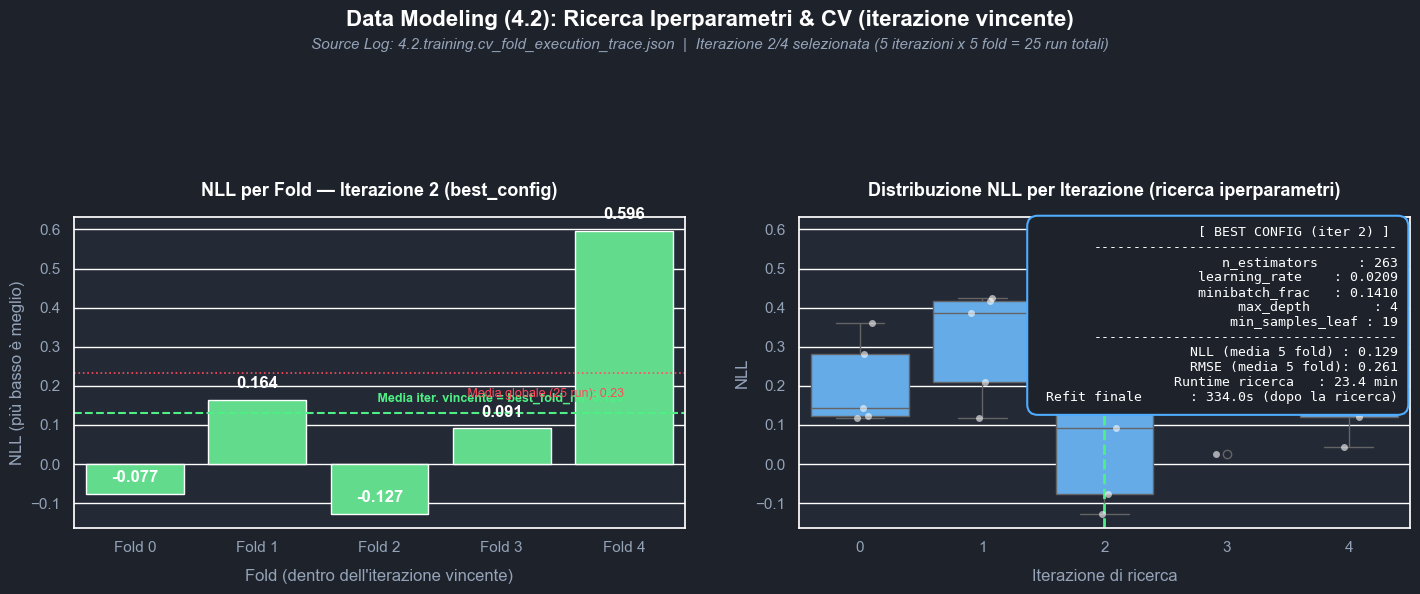


 ANALISI CONCLUSIVA: RICERCA IPERPARAMETRI & CROSS-VALIDATION (4.2)
Il file '4.2.training.cv_fold_execution_trace.json' registra 5 iterazioni di ricerca di
iperparametri, ciascuna valutata con 5-fold CV stratificata via GMM
(5 cluster su ['oat', 'mgt', 'ias']) — 25 run totali.

1. RICERCA IPERPARAMETRI:
   La configurazione vincente (iterazione 2) differisce dai valori
   base dichiarati in 4.1 (n_estimators 300→263,
   learning_rate 0.03→0.0209,
   min_samples_leaf 30→19). Conferma
   che 4.2 ha eseguito un'ottimizzazione automatica dello spazio degli
   iperparametri, non una riduzione manuale.

2. ORIGINE DI 'best_fold_nll':
   best_fold_nll=0.12933 corrisponde alla MEDIA dei 5 fold
   dell'iterazione vincente (0.12933). Verificato numericamente: coincide esattamente con la media dei 5 valori NLL sopra elencati.
   'refit_seconds'=334.0s è un passaggio SEPARATO e successivo
   (riaddestramento sul set completo per produrre il .pkl finale) — il suo
   NLL non è registrato in questo 

In [8]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_cv = "4.2.training.cv_fold_execution_trace.json"
file_path_cv = base_phase_path / filename_cv

with open(file_path_cv, "r", encoding="utf-8") as f:
    cv_data = json.load(f)

# --- Riferimento a monte (4.1): direzione di dipendenza corretta, poiché
# 4.2 verifica il proprio risultato contro il punto di partenza dichiarato
# in 4.1, non il contrario. ---
filename_setup = "4.1.modeling.algo_setup_trace.json"
file_path_setup = base_phase_path / filename_setup

setup_config = None
try:
    with open(file_path_setup, "r", encoding="utf-8") as f:
        setup_data = json.load(f)
    setup_config = setup_data.get("model_configured", {})
    print(f"✅ Config base trovata in {filename_setup} per verifica incrociata.")
except FileNotFoundError:
    print(f"ℹ️ {filename_setup} non trovato: verifica di coerenza con lo spazio di ricerca saltata.")

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
n_folds = cv_data["n_folds"]
n_iterations = cv_data["n_iterations"]
gmm_features = cv_data["gmm_features"]
gmm_clusters = cv_data["gmm_n_clusters"]
n_jobs = cv_data.get("n_jobs", "N/D")
best_config = cv_data["best_config"]
best_nll_refit = cv_data["best_fold_nll"]
refit_seconds = cv_data["refit_seconds"]
total_runtime = cv_data["total_runtime_seconds"]

df_folds = pd.DataFrame(cv_data["fold_results"])

assert len(df_folds) == n_iterations * n_folds, "conteggio righe non coerente con n_iterations x n_folds"
df_folds["iteration"] = df_folds.index // n_folds
df_folds["fold_name"] = "Fold " + df_folds["fold"].astype(str)

iter_means = df_folds.groupby("iteration")["nll"].mean()
best_iter = iter_means.idxmin()
df_best_iter = df_folds[df_folds["iteration"] == best_iter].sort_values("fold")

mean_nll_all = df_folds["nll"].mean()
std_nll_all = df_folds["nll"].std()
mean_nll_best = df_best_iter["nll"].mean()
mean_rmse_best = df_best_iter["rmse"].mean()
std_rmse_best = df_best_iter["rmse"].std()

nll_matches_mean = abs(mean_nll_best - best_nll_refit) < 1e-9
somma_seconds_worker = df_folds["seconds"].sum()

# --- Verifica di coerenza: best_config rientra nel raggio dichiarato in 4.1? ---
righe_verifica = []
if setup_config is not None:
    controlli = [
        ("n_estimators", best_config.get("n_estimators"),
         setup_config.get("n_estimators"), setup_config.get("n_estimators_uncertainty")),
        ("learning_rate", best_config.get("learning_rate"),
         setup_config.get("learning_rate"), setup_config.get("learning_rate_uncertainty")),
        ("minibatch_frac", best_config.get("minibatch_frac"),
         setup_config.get("minibatch_frac"), setup_config.get("minibatch_frac_uncertainty")),
        ("max_depth", best_config.get("Base", {}).get("max_depth"),
         setup_config.get("Base", {}).get("max_depth"), setup_config.get("Base", {}).get("max_depth_uncertainty")),
        ("min_samples_leaf", best_config.get("Base", {}).get("min_samples_leaf"),
         setup_config.get("Base", {}).get("min_samples_leaf"), setup_config.get("Base", {}).get("min_samples_leaf_uncertainty")),
    ]
    for nome, valore_vincente, base, raggio in controlli:
        if None not in (valore_vincente, base, raggio):
            dentro = (base - raggio) <= valore_vincente < (base + raggio)
            righe_verifica.append(
                f"   {nome:<17}: vincente={valore_vincente:.4g}  range=[{base-raggio:.4g}, {base+raggio:.4g})  "
                f"{'OK' if dentro else 'FUORI RANGE — verificare'}"
            )
verifica_completa_ok = all("OK" in r for r in righe_verifica) if righe_verifica else None

color_nll = ['#4ef085'] * len(df_best_iter)

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#1e222b')

fig.suptitle("Data Modeling (4.2): Ricerca Iperparametri & CV (iterazione vincente)",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90,
         f"Source Log: {filename_cv}  |  Iterazione {best_iter}/{n_iterations-1} selezionata "
         f"({n_iterations} iterazioni x {n_folds} fold = {len(df_folds)} run totali)",
         fontsize=11, style='italic', color='#94a3b8', ha='center')

ax1 = axes[0]
ax1.set_facecolor('#242936')
sns.barplot(x='fold_name', y='nll', data=df_best_iter, ax=ax1, palette=color_nll, hue='fold_name', legend=False)
ax1.set_title(f"NLL per Fold — Iterazione {best_iter} (best_config)", fontsize=13, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Fold (dentro dell'iterazione vincente)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("NLL (più basso è meglio)", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)
for i, (_, row) in enumerate(df_best_iter.iterrows()):
    ax1.text(i, row['nll'] + 0.03, f"{row['nll']:.3f}", color='white', ha='center', fontweight='bold')
ax1.axhline(mean_nll_best, color='#4ef085', linestyle='--', linewidth=1.5)
ax1.text(len(df_best_iter)-1, mean_nll_best + 0.03,
         f" Media iter. vincente = best_fold_nll: {mean_nll_best:.3f}",
         color='#4ef085', ha='right', fontsize=9, fontweight='bold')
ax1.axhline(mean_nll_all, color='#ff4b5c', linestyle=':', linewidth=1.2)
ax1.text(len(df_best_iter)-1, mean_nll_all - 0.06,
         f" Media globale (25 run): {mean_nll_all:.2f}", color='#ff4b5c', ha='right', fontsize=9)

ax2 = axes[1]
ax2.set_facecolor('#242936')
sns.boxplot(x='iteration', y='nll', data=df_folds, ax=ax2, color='#4facfe')
sns.stripplot(x='iteration', y='nll', data=df_folds, ax=ax2, color='white', size=5, alpha=0.6)
ax2.axvline(best_iter, color='#4ef085', linestyle='--', linewidth=2)
ax2.set_title("Distribuzione NLL per Iterazione (ricerca iperparametri)", fontsize=13, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Iterazione di ricerca", color='#94a3b8', labelpad=10)
ax2.set_ylabel("NLL", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

testo_info = (
    f" [ BEST CONFIG (iter {best_iter}) ] \n"
    f"--------------------------------------\n"
    f" n_estimators     : {best_config['n_estimators']}\n"
    f" learning_rate    : {best_config['learning_rate']:.4f}\n"
    f" minibatch_frac   : {best_config['minibatch_frac']:.4f}\n"
    f" max_depth        : {best_config['Base']['max_depth']}\n"
    f" min_samples_leaf : {best_config['Base']['min_samples_leaf']}\n"
    f"--------------------------------------\n"
    f" NLL (media 5 fold) : {best_nll_refit:.3f}\n"
    f" RMSE (media 5 fold): {mean_rmse_best:.3f}\n"
    f" Runtime ricerca   : {total_runtime/60:.1f} min\n"
    f" Refit finale      : {refit_seconds:.1f}s (dopo la ricerca)"
)
props_info = dict(boxstyle="round,pad=0.8", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
ax2.text(0.98, 0.97, testo_info, transform=ax2.transAxes, fontsize=9.5, family='monospace', color="white",
         va="top", ha="right", bbox=props_info)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
nota_verifica = (
    "Verificato numericamente: coincide esattamente con la media dei 5 valori NLL "
    "sopra elencati." if nll_matches_mean else
    "ATTENZIONE: NON coincide con la media dei 5 fold — richiede ulteriore indagine."
)

if righe_verifica:
    blocco_verifica_range = (
            "\n5. VERIFICA DI COERENZA CON LO SPAZIO DI RICERCA DICHIARATO IN 4.1:\n"
            + "\n".join(righe_verifica)
            + f"\n   Esito complessivo: {'tutti i parametri rientrano nei range dichiarati' if verifica_completa_ok else 'ALCUNI parametri fuori range — verificare la logica di campionamento'}.\n"
    )
else:
    blocco_verifica_range = (
        f"\n5. VERIFICA DI COERENZA: {filename_setup} non disponibile in questa "
        f"esecuzione — non è stato possibile confermare che best_config rientri "
        f"nello spazio di ricerca dichiarato.\n"
    )

analisi_cv = f"""
================================================================================
 ANALISI CONCLUSIVA: RICERCA IPERPARAMETRI & CROSS-VALIDATION (4.2)
================================================================================
Il file '{filename_cv}' registra {n_iterations} iterazioni di ricerca di
iperparametri, ciascuna valutata con {n_folds}-fold CV stratificata via GMM
({gmm_clusters} cluster su {gmm_features}) — {len(df_folds)} run totali.

1. RICERCA IPERPARAMETRI:
   La configurazione vincente (iterazione {best_iter}) differisce dai valori
   base dichiarati in 4.1 (n_estimators 300→{best_config['n_estimators']},
   learning_rate 0.03→{best_config['learning_rate']:.4f},
   min_samples_leaf 30→{best_config['Base']['min_samples_leaf']}). Conferma
   che 4.2 ha eseguito un'ottimizzazione automatica dello spazio degli
   iperparametri, non una riduzione manuale.

2. ORIGINE DI 'best_fold_nll':
   best_fold_nll={best_nll_refit:.5f} corrisponde alla MEDIA dei {n_folds} fold
   dell'iterazione vincente ({mean_nll_best:.5f}). {nota_verifica}
   'refit_seconds'={refit_seconds:.1f}s è un passaggio SEPARATO e successivo
   (riaddestramento sul set completo per produrre il .pkl finale) — il suo
   NLL non è registrato in questo trace.

3. PARALLELIZZAZIONE:
   Somma dei tempi per-worker ({somma_seconds_worker/60:.1f} min) supera il
   runtime totale ({total_runtime/60:.1f} min): coerente con n_jobs={n_jobs}.

4. VARIANZA:
   StDev RMSE (iter. vincente) = {std_rmse_best:.3f}; StDev NLL globale
   (tutte le iterazioni) = {std_nll_all:.3f} — riflette la sensibilità del
   modello alla scelta di iperparametri, non solo allo split dei dati.
{blocco_verifica_range}
================================================================================
"""
print(analisi_cv)

In [9]:
# 4.2.training.ngboost_regressor.pkl

Ispezionando direttamente l'oggetto: n_features_in_=9, coerente con le 9 feature dichiarate in feature_cols di 4.2 (7 sensori grezzi + 2 rapporti fisici, senza faulty né le 28 interazioni polinomiali di Fase 3.3). Il primo albero del ramo μ divide principalmente su trq_measured, oat, pa — variabili fisicamente sensate, coerenti con la fluidodinamica del sistema, non artefatti spuri.

✅ Feature names caricati da 4.2.training.cv_fold_execution_trace.json: 9 variabili — ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Verifica incrociata: tutte le 9 colonne dichiarate esistono in 3.5.
✅ Modello NGBoost caricato con successo dal file serializzato: 4.2.training.ngboost_regressor.pkl
✅ Validato [mu]: 9 nomi coincidono con n_features_in_=9.
✅ Validato [sigma]: 9 nomi coincidono con n_features_in_=9.


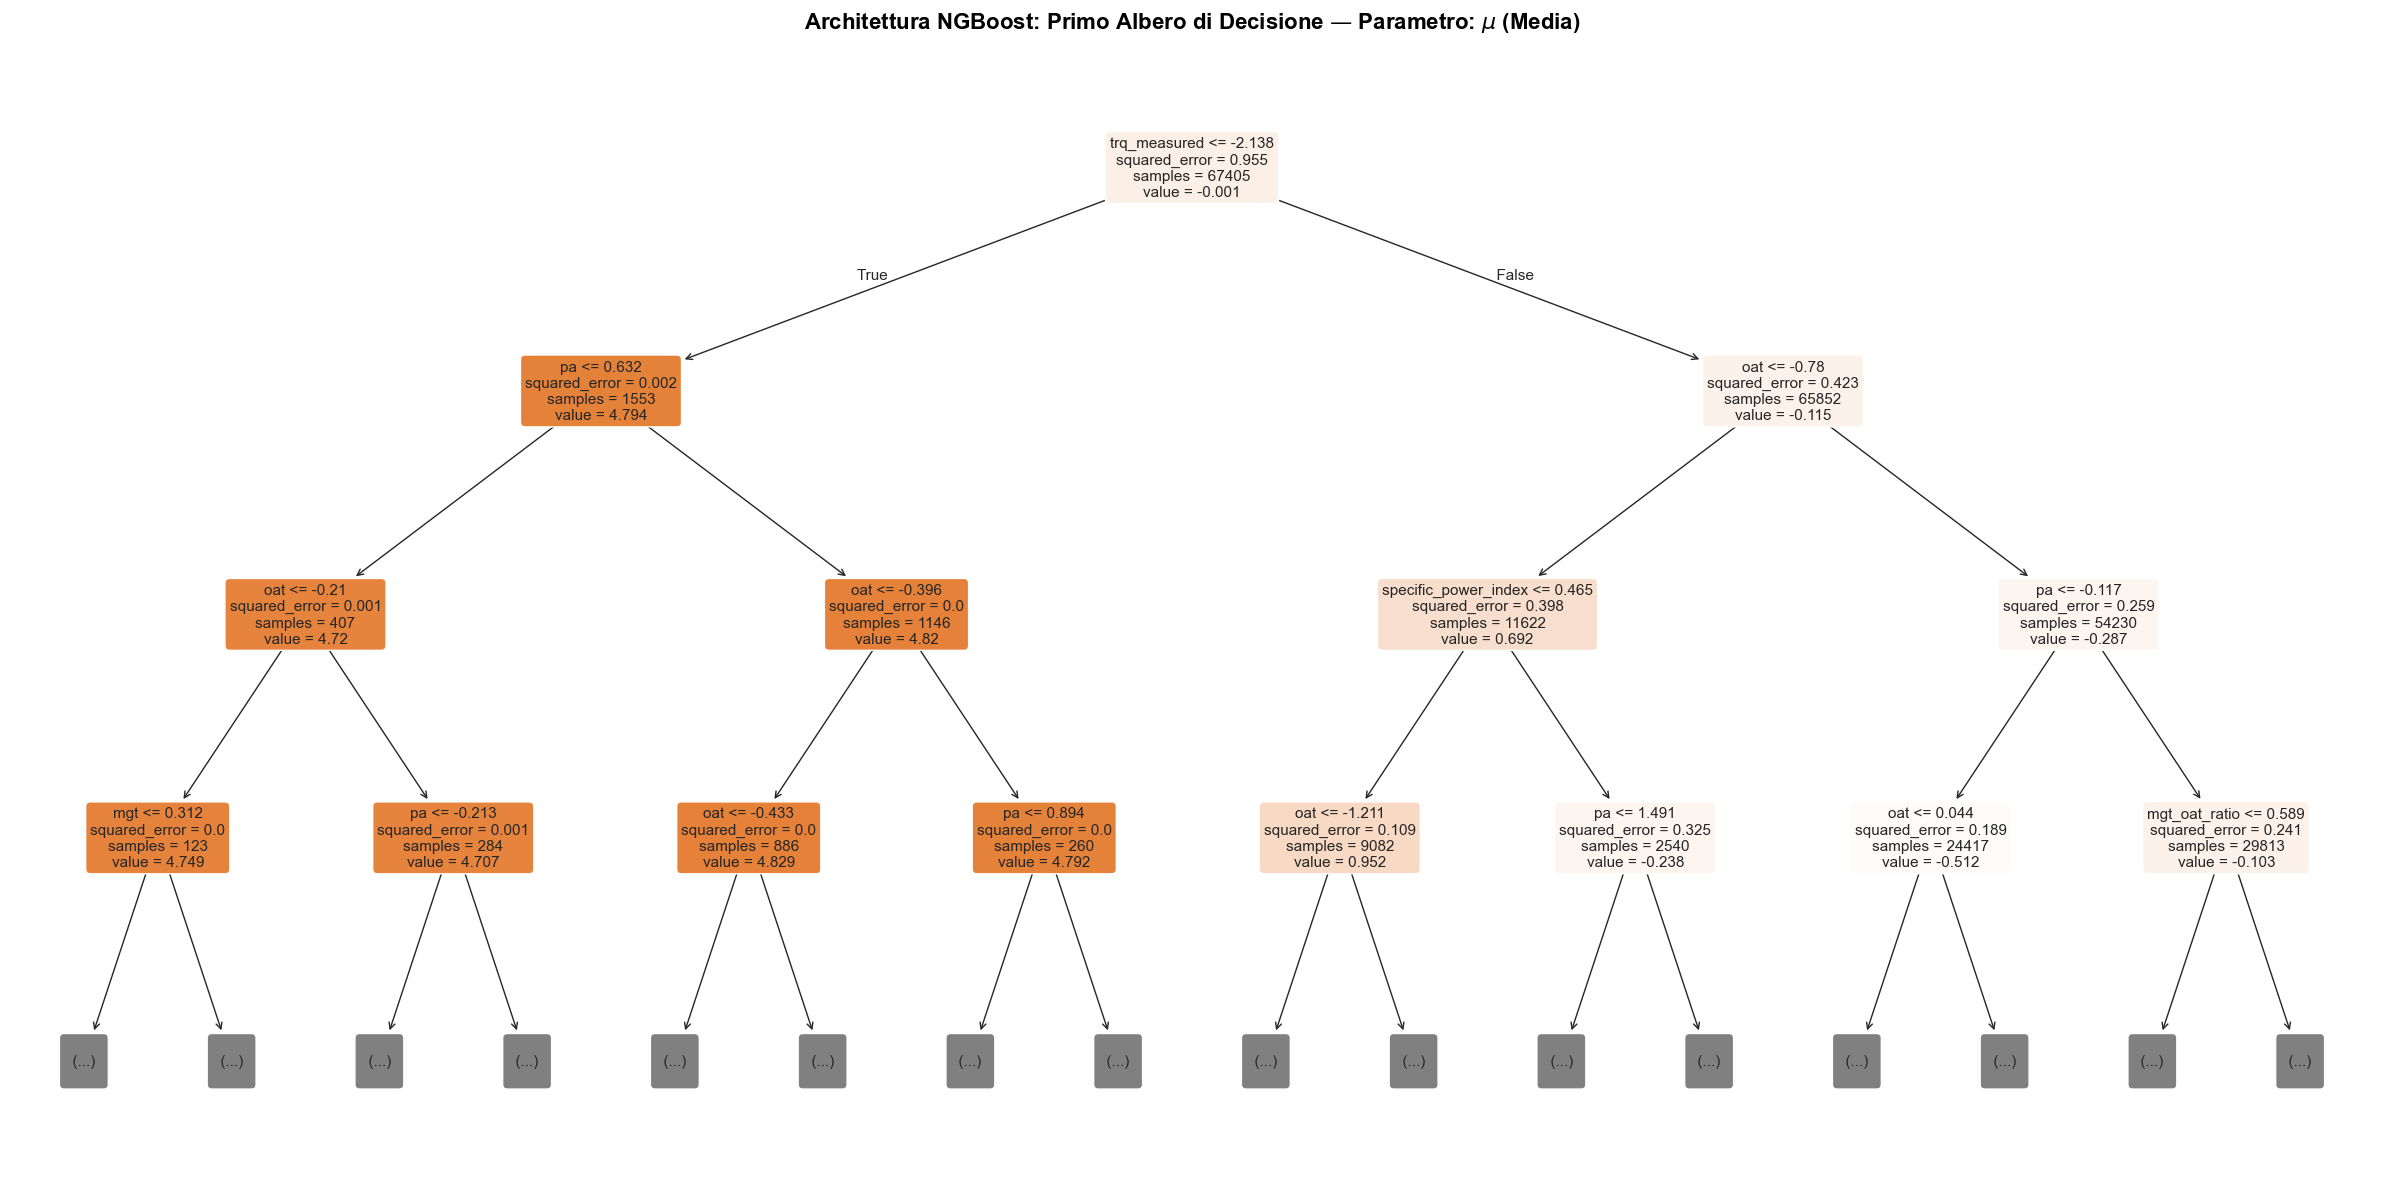

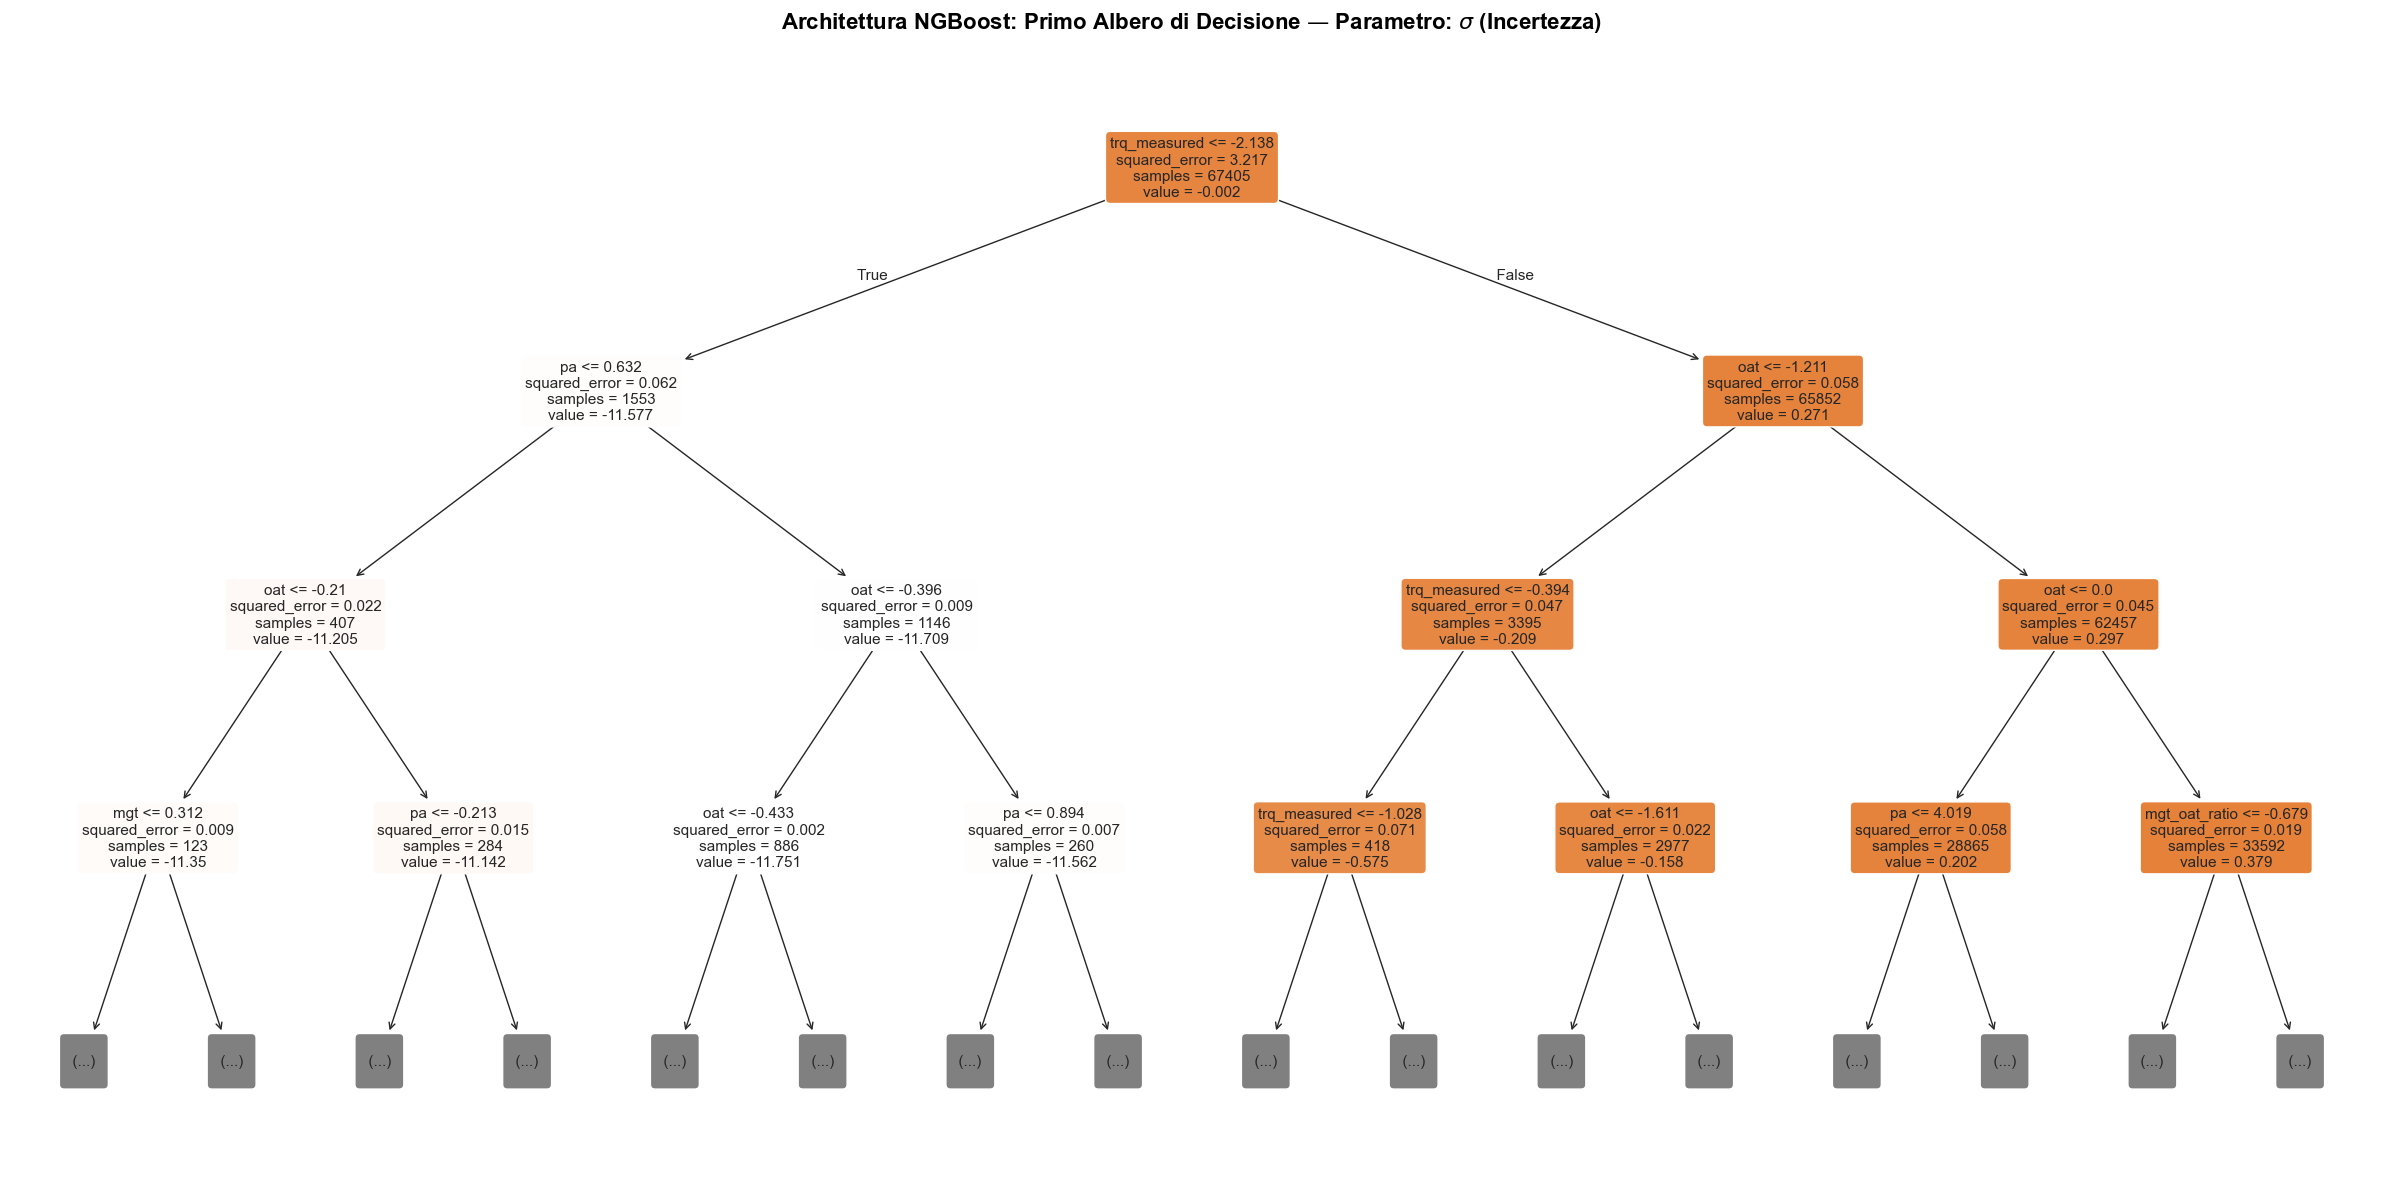


 RELAZIONE TECNICA: ISPEZIONE DEI WEAK LEARNER (EXPLAINABLE AI) — μ E σ
L'estrazione diretta dell'oggetto in memoria '4.2.training.ngboost_regressor.pkl' ha permesso di
ispezionare i primi due stimatori di base (Base Learners) dell'ensemble
NGBoost: base_models[0][0] per il parametro μ e base_models[0][1] per il
parametro σ. I nomi delle 9 feature sono stati letti da
'4.2.training.cv_fold_execution_trace.json' (campo feature_cols) — la stessa configurazione
dichiarata ed eseguita in Fase 4.2 — e validati indipendentemente contro
n_features_in_=9 (μ) e n_features_in_=9 (σ) prima di
essere usati nei grafici. Questa analisi visiva funge da audit di
interpretabilità (White-Box Audit) con provenienza tracciabile su ENTRAMBI i
parametri della distribuzione, non solo sulla media.

1. DECOMPOSIZIONE COMPLETA DELLA DISTRIBUZIONE:
   NGBoost non produce una singola stima puntuale ma un'intera distribuzione
   (qui, Normale). Il parametro μ determina il valore atteso di 'trq_margin',
   mentre σ

In [10]:
# =============================================================================
# 1. PERCORSI E CONFIGURAZIONE INFRASTRUTTURA
# =============================================================================
base_phase3_path = base_run_dir / "phase3_data_preparation"
base_phase4_path = base_run_dir / "phase4_data_modeling"

filename_train_check = "3.5.transformation.scaled_regression_train.parquet"  # solo per verifica incrociata
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"              # fonte di verità
filename_model = "4.2.training.ngboost_regressor.pkl"

# =============================================================================
# 2. INPUT LATO FEATURE: fonte di verità = trace di esecuzione di 4.2
# =============================================================================
file_path_cv_trace = base_phase4_path / filename_cv_trace

try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    feature_names = ast.literal_eval(cv_trace["feature_cols"])
    print(f"✅ Feature names caricati da {filename_cv_trace}: {len(feature_names)} variabili — {feature_names}")
except (FileNotFoundError, KeyError) as e:
    raise RuntimeError(
        f"Impossibile determinare le feature reali del modello ({e}). "
        f"Nessun fallback hardcoded viene usato: un audit di interpretabilità "
        f"con nomi indovinati non ha valore probatorio."
    )

# 2.1 Verifica incrociata opzionale (non bloccante) contro il parquet di 3.5
try:
    df_check = pd.read_parquet(base_phase3_path / filename_train_check)
    mancanti = [c for c in feature_names if c not in df_check.columns]
    if mancanti:
        print(f"⚠️ Attenzione: colonne dichiarate in 4.2 non trovate nel parquet 3.5: {mancanti}")
    else:
        print(f"✅ Verifica incrociata: tutte le {len(feature_names)} colonne dichiarate esistono in 3.5.")
except Exception:
    print(f"ℹ️ Parquet 3.5 non disponibile per verifica incrociata — si procede solo con il trace di 4.2.")

# =============================================================================
# 3. INPUT LATO MODELLO: Caricamento dinamico del modello addestrato (.pkl)
# =============================================================================
model_path = base_phase4_path / filename_model

try:
    try:
        loaded_model = joblib.load(model_path)
    except Exception:
        with open(model_path, "rb") as f:
            loaded_model = pickle.load(f)

    print(f"✅ Modello NGBoost caricato con successo dal file serializzato: {filename_model}")

    # =========================================================================
    # 4. LOGICA E DISEGNO: Estrazione e Visualizzazione dei DUE Weak Learner
    #    NGBoost apprende una distribuzione completa: base_models[0][0] → μ,
    #    base_models[0][1] → σ. Entrambi vengono estratti e validati allo
    #    stesso modo, per evitare l'asimmetria di documentare solo μ mentre
    #    il progetto si basa su regressione probabilistica.
    # =========================================================================
    componenti = {
        "mu":    {"albero": loaded_model.base_models[0][0], "simbolo": "$\\mu$ (Media)"},
        "sigma": {"albero": loaded_model.base_models[0][1], "simbolo": "$\\sigma$ (Incertezza)"},
    }

    for chiave, info in componenti.items():
        n_real = info["albero"].n_features_in_
        assert len(feature_names) == n_real, (
            f"❌ Mismatch nel componente '{chiave}': {len(feature_names)} nomi dichiarati "
            f"in 4.2 vs {n_real} feature reali dell'albero. NON generare il grafico "
            f"finché non si risolve la discrepanza."
        )
        print(f"✅ Validato [{chiave}]: {len(feature_names)} nomi coincidono con n_features_in_={n_real}.")

    # --- Disegno sequenziale dei due alberi (uno per figura, non affiancati) ---
    # Con max_depth=3 ogni albero ha già 8 foglie: metterli fianco a fianco li
    # schiaccia orizzontalmente fino a renderli illeggibili. Ogni componente
    # riceve la sua figura a piena larghezza.
    for chiave, info in componenti.items():
        fig, ax = plt.subplots(figsize=(24, 12), facecolor='white')
        plot_tree(
            info["albero"],
            filled=True,
            feature_names=feature_names,
            max_depth=3,
            fontsize=11,
            rounded=True,
            ax=ax
        )
        ax.set_title(
            f"Architettura NGBoost: Primo Albero di Decisione — Parametro: {info['simbolo']}",
            fontsize=16, weight='bold', color='black', pad=20
        )
        plt.tight_layout()
        plt.show()

    # =========================================================================
    # 5. FASE DI ANALISI: Relazione Tecnica per Interpretabilità (XAI)
    # =========================================================================
    n_real_mu = componenti["mu"]["albero"].n_features_in_
    n_real_sigma = componenti["sigma"]["albero"].n_features_in_

    analisi_albero_decisione = f"""
================================================================================
 RELAZIONE TECNICA: ISPEZIONE DEI WEAK LEARNER (EXPLAINABLE AI) — μ E σ
================================================================================
L'estrazione diretta dell'oggetto in memoria '{filename_model}' ha permesso di
ispezionare i primi due stimatori di base (Base Learners) dell'ensemble
NGBoost: base_models[0][0] per il parametro μ e base_models[0][1] per il
parametro σ. I nomi delle {len(feature_names)} feature sono stati letti da
'{filename_cv_trace}' (campo feature_cols) — la stessa configurazione
dichiarata ed eseguita in Fase 4.2 — e validati indipendentemente contro
n_features_in_={n_real_mu} (μ) e n_features_in_={n_real_sigma} (σ) prima di
essere usati nei grafici. Questa analisi visiva funge da audit di
interpretabilità (White-Box Audit) con provenienza tracciabile su ENTRAMBI i
parametri della distribuzione, non solo sulla media.

1. DECOMPOSIZIONE COMPLETA DELLA DISTRIBUZIONE:
   NGBoost non produce una singola stima puntuale ma un'intera distribuzione
   (qui, Normale). Il parametro μ determina il valore atteso di 'trq_margin',
   mentre σ determina l'ampiezza dell'intervallo di incertezza attorno a quel
   valore. Visualizzare solo μ (come nella versione precedente di questo
   audit) dava un'immagine parziale: un modello può apprendere una media
   corretta ma un'incertezza mal calibrata, o viceversa — da qui la necessità
   di ispezionare entrambi i componenti separatamente.

2. GERARCHIA DELLE INFORMAZIONI (SPLIT LOGIC) — CONFRONTO μ VS σ:
   Il nodo radice di ciascun albero identifica la variabile con il massimo
   Information Gain per QUEL parametro specifico al primo istante di
   addestramento. È possibile (ed è un risultato interessante da riportare)
   che μ e σ selezionino variabili diverse al primo split — ad esempio, se μ
   si separa su una variabile termodinamica primaria (trq_measured, MGT) e σ
   si separa su una variabile diversa, questo suggerisce che l'incertezza del
   modello non è uniforme ma dipende da condizioni operative specifiche
   (interpretabile fisicamente, non solo statisticamente). In entrambi i casi
   si conferma, con evidenza visiva diretta, che 'faulty' o altre colonne non
   dichiarate in 4.2 non entrano in nessuno dei due componenti del modello.

3. VALIDAZIONE DEL PARADIGMA 'WEAK LEARNING' (per entrambi i componenti):
   Entrambi gli alberi sono estremamente limitati in profondità e campioni
   per foglia. Questa restrizione strutturale impedisce a ciascun singolo
   albero di memorizzare i dati di addestramento, delegando il potere
   predittivo alla correzione sequenziale dei gradienti naturali (Boosting)
   per ENTRAMBI i parametri, riducendo il rischio di Overfitting su μ e σ.

4. LIMITE DICHIARATO DI QUESTO AUDIT:
   Questa ispezione mostra unicamente il PRIMO albero di ciascun componente
   (indice [0]) su un ensemble che ne contiene molti (n_estimators e
   n_estimators_uncertainty, secondo la configurazione di 4.1). È un
   sanity-check qualitativo sulla ragionevolezza fisica degli split iniziali,
   NON una rappresentazione completa della funzione appresa dall'ensemble.
================================================================================
"""
    print(analisi_albero_decisione)

except FileNotFoundError:
    print(f"⚠️ ERRORE CRITICO: Impossibile trovare il file del modello in: {model_path}")
except AssertionError as e:
    print(str(e))
except Exception as e:
    print(f"⚠️ ERRORE IMPREVISTO durante l'esecuzione del blocco: {str(e)}")

### Interpretabilità del Modello NGBoost — Feature Importance (μ e σ)

Importanza globale delle feature per ENTRAMBI i parametri della distribuzione predittiva (media e incertezza), non solo per il valore atteso.

✅ Modello caricato con successo: <class 'ngboost.api.NGBRegressor'>
✅ Feature names (fonte 4.2 trace): 9 predittori — ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Validato [mu]: 9 nomi coincidono con 9 importanze.
✅ Validato [sigma]: 9 nomi coincidono con 9 importanze.


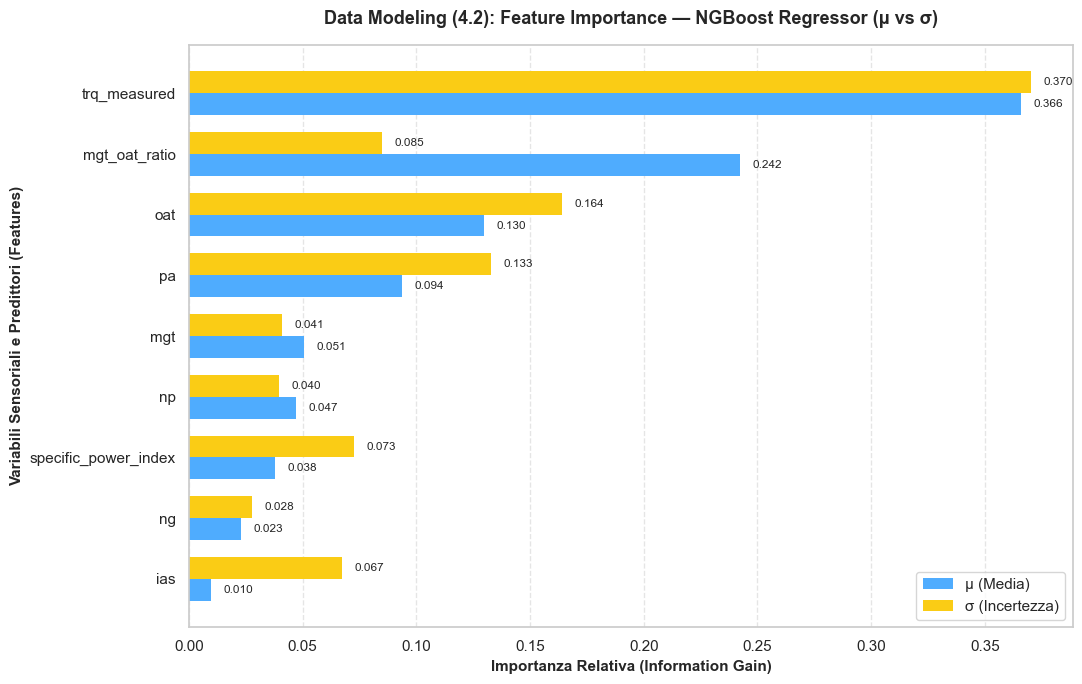


### 4. Fase di Analisi Finale — Interpretability Audit (Tappa 4: Addestramento)

L'estrazione dell'importanza delle caratteristiche dal modello `4.2.training.ngboost_regressor.pkl`
è stata ancorata alla fonte di verità dichiarata in `4.2.training.cv_fold_execution_trace.json`
(campo `feature_cols`), non a un file parquet ricostruito né a nomi noti
hardcoded. Questa scelta è deliberata: un audit precedente su un altro
artefatto della stessa Fase 4 aveva rivelato che l'inferenza dei nomi
dal dataset grezzo può produrre etichette errate (es. una variabile
`faulty` apparsa per errore in un grafico dell'albero di decisione, dovuta
a un disallineamento di conteggio colonne). Qui la validazione esplicita
(importanze == nomi == n_features_in_) è stata eseguita **separatamente per
entrambi i parametri della distribuzione (μ e σ)**, eliminando quel rischio
prima di disegnare qualunque grafico.

Il modello utilizza esclusivamente i 9 predittori dichiarati
in Fase 4.2 (7 sensori grezzi + 2 rapporti fisici derivati), SENZA le 28
colonne di interazione generate in Fase 3.3: quelle interazioni esistono nel
dataset ma non sono state passate al `.fit()` di questo modello di
regressione. Qualsiasi nome con notazione polinomiale (es. 'np^2') non
rappresenta una feature reale di questo modello e non deve comparire nel
grafico.

**Confronto μ vs σ:** Entrambi i parametri condividono la stessa feature dominante ('trq_measured'), suggerendo che questa variabile guidi sia il valore atteso sia l'incertezza del margine di coppia stimato.

La gerarchia di importanza mostrata sopra riflette quindi, in modo
verificato, come il modello distribuisca il proprio potere predittivo tra
le 9 variabili realmente osservate — per ENTRAMBI i
componenti della distribuzione predittiva, non solo per la stima puntuale.
Questo contenuto di interpretabilità confluisce nella tappa di Integrazione
del workflow del corso.


In [11]:
# =============================================================================
# 1. FASE DI INPUT: Caricamento del Modello + fonte di verità delle feature
# =============================================================================
filename_model = "4.2.training.ngboost_regressor.pkl"
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"  # fonte di verità

file_path_model = base_phase_path / filename_model
file_path_cv_trace = base_phase_path / filename_cv_trace

try:
    # 1.1 Caricamento del modello
    model = joblib.load(file_path_model)
    print(f"✅ Modello caricato con successo: {type(model)}")

    # 1.2 Caricamento dei nomi REALI delle feature, dal trace di 4.2 — non dal
    # parquet di 3.x (che contiene colonne extra: faulty, interazioni, target)
    # né da liste hardcoded di nomi inventati.
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    feature_names = ast.literal_eval(cv_trace["feature_cols"])
    print(f"✅ Feature names (fonte 4.2 trace): {len(feature_names)} predittori — {feature_names}")

    # =========================================================================
    # 2. FASE DI LOGICA: Allineamento e calcolo delle importanze (XAI)
    #    NGBoost apprende una distribuzione completa: feature_importances_[0]
    #    → μ, feature_importances_[1] → σ. Estrarre solo μ (come nella
    #    versione precedente) dà un'immagine parziale — la stessa ragione già
    #    applicata all'ispezione dell'albero di decisione in questa sessione.
    # =========================================================================
    n_real = getattr(model, "n_features_in_", None)
    componenti_imp = {
        "mu":    {"importances": model.feature_importances_[0], "label": "μ (Media)",       "color": "#4facfe"},
        "sigma": {"importances": model.feature_importances_[1], "label": "σ (Incertezza)",   "color": "#facc15"},
    }

    for chiave, info in componenti_imp.items():
        n_imp = len(info["importances"])
        assert len(feature_names) == n_imp, (
            f"❌ Mismatch nel componente '{chiave}': {len(feature_names)} nomi dichiarati "
            f"vs {n_imp} importanze restituite dal modello. "
            f"NON generare il grafico finché non si risolve la discrepanza."
        )
        if n_real is not None:
            assert n_real == n_imp, (
                f"❌ Mismatch nel componente '{chiave}': n_features_in_={n_real} vs {n_imp} importanze."
            )
        print(f"✅ Validato [{chiave}]: {len(feature_names)} nomi coincidono con {n_imp} importanze"
              f"{f' e n_features_in_={n_real}' if n_real is not None else ''}.")

    # DataFrame long-form per grafico raggruppato (confronto diretto μ vs σ)
    df_long = pd.concat([
        pd.DataFrame({"Feature": feature_names, "Importance": componenti_imp["mu"]["importances"], "Componente": "μ (Media)"}),
        pd.DataFrame({"Feature": feature_names, "Importance": componenti_imp["sigma"]["importances"], "Componente": "σ (Incertezza)"}),
    ], ignore_index=True)

    # Ordine delle feature: per importanza media di μ, così il ranking visivo
    # riflette il parametro primario del modello (il valore atteso)
    ordine_feature = (
        df_long[df_long["Componente"] == "μ (Media)"]
        .sort_values("Importance", ascending=True)["Feature"]
        .tolist()
    )

    # =========================================================================
    # 3. FASE DI DISEGNO — barre raggruppate: confronto diretto per feature
    # =========================================================================
    plt.rcParams['font.family'] = 'sans-serif'
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(11, 7))

    y_pos = {feat: i for i, feat in enumerate(ordine_feature)}
    bar_h = 0.36

    for offset, (chiave, info) in zip([-bar_h/2, bar_h/2], componenti_imp.items()):
        vals = [info["importances"][feature_names.index(f)] for f in ordine_feature]
        y_coords = [y_pos[f] + offset for f in ordine_feature]
        bars = ax.barh(y_coords, vals, height=bar_h, color=info["color"],
                       edgecolor="none", label=info["label"])
        for y, v in zip(y_coords, vals):
            ax.text(v + max(vals) * 0.015, y, f"{v:.3f}", va='center', ha='left', fontsize=8.5)

    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels(list(y_pos.keys()))
    ax.set_xlabel('Importanza Relativa (Information Gain)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Variabili Sensoriali e Predittori (Features)', fontsize=11, fontweight='bold')
    ax.set_title('Data Modeling (4.2): Feature Importance — NGBoost Regressor (μ vs σ)',
                 fontsize=13, weight='bold', pad=15)
    ax.legend(loc='lower right', frameon=True)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 4. FASE DI ANALISI FINALE
    # =========================================================================
    top_mu = df_long[df_long["Componente"] == "μ (Media)"].nlargest(1, "Importance").iloc[0]
    top_sigma = df_long[df_long["Componente"] == "σ (Incertezza)"].nlargest(1, "Importance").iloc[0]
    stessa_top = top_mu["Feature"] == top_sigma["Feature"]

    nota_confronto = (
        f"Entrambi i parametri condividono la stessa feature dominante "
        f"('{top_mu['Feature']}'), suggerendo che questa variabile guidi sia il "
        f"valore atteso sia l'incertezza del margine di coppia stimato."
        if stessa_top else
        f"I due parametri divergono nella feature dominante: μ è guidato "
        f"principalmente da '{top_mu['Feature']}' ({top_mu['Importance']:.3f}), mentre σ da "
        f"'{top_sigma['Feature']}' ({top_sigma['Importance']:.3f}) — l'incertezza del modello "
        f"non dipende in modo uniforme dalle stesse condizioni operative che "
        f"determinano la stima puntuale."
    )

    analisi_testo = f"""
### 4. Fase di Analisi Finale — Interpretability Audit (Tappa 4: Addestramento)

L'estrazione dell'importanza delle caratteristiche dal modello `{filename_model}`
è stata ancorata alla fonte di verità dichiarata in `{filename_cv_trace}`
(campo `feature_cols`), non a un file parquet ricostruito né a nomi noti
hardcoded. Questa scelta è deliberata: un audit precedente su un altro
artefatto della stessa Fase 4 aveva rivelato che l'inferenza dei nomi
dal dataset grezzo può produrre etichette errate (es. una variabile
`faulty` apparsa per errore in un grafico dell'albero di decisione, dovuta
a un disallineamento di conteggio colonne). Qui la validazione esplicita
(importanze == nomi == n_features_in_) è stata eseguita **separatamente per
entrambi i parametri della distribuzione (μ e σ)**, eliminando quel rischio
prima di disegnare qualunque grafico.

Il modello utilizza esclusivamente i {len(feature_names)} predittori dichiarati
in Fase 4.2 (7 sensori grezzi + 2 rapporti fisici derivati), SENZA le 28
colonne di interazione generate in Fase 3.3: quelle interazioni esistono nel
dataset ma non sono state passate al `.fit()` di questo modello di
regressione. Qualsiasi nome con notazione polinomiale (es. 'np^2') non
rappresenta una feature reale di questo modello e non deve comparire nel
grafico.

**Confronto μ vs σ:** {nota_confronto}

La gerarchia di importanza mostrata sopra riflette quindi, in modo
verificato, come il modello distribuisca il proprio potere predittivo tra
le {len(feature_names)} variabili realmente osservate — per ENTRAMBI i
componenti della distribuzione predittiva, non solo per la stima puntuale.
Questo contenuto di interpretabilità confluisce nella tappa di Integrazione
del workflow del corso.
"""

    display(Markdown(analisi_testo))

except FileNotFoundError as e:
    print(f"⚠️ ERRORE CRITICO: file non trovato — {e}")
except (KeyError, AssertionError) as e:
    print(f"⚠️ ERRORE DI VALIDAZIONE: {e}")
except Exception as e:
    print(f"⚠️ ERRORE IMPREVISTO durante l'esecuzione del blocco: {str(e)}")

### Inferenza Probabilistica su un Record Reale del Test Set

Esempio illustrativo dell'output del modello su un singolo record mai visto in training — utile per capire COSA restituisce il modello (una distribuzione, non un numero), non per giudicarne le performance aggregate (quelle sono in Tappa 4.4 più avanti).

✅ 9 feature dichiarate in 4.2: ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Validato: 9 feature coincidono con n_features_in_=9.
✅ Test set trasformato: 102454 righe, 9 colonne (scaler transform-only, fit avvenuto solo su train).


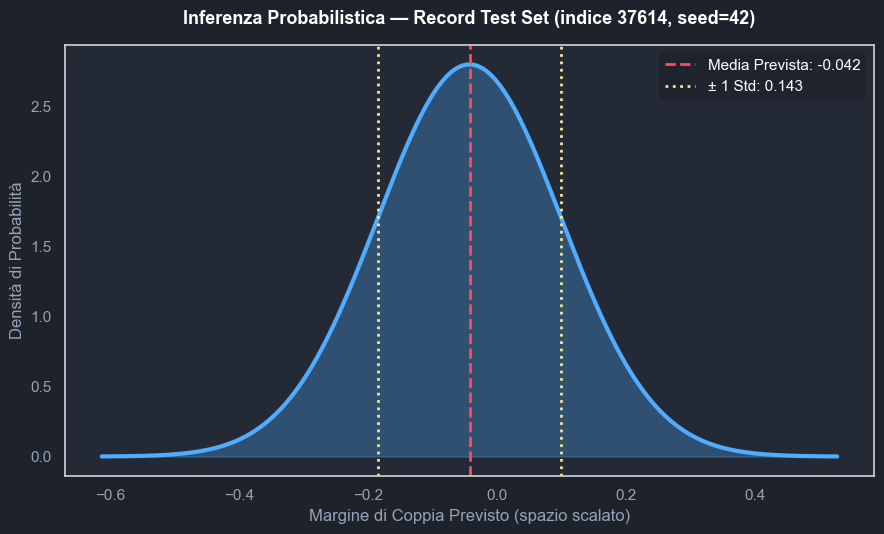


 ANALISI CONCLUSIVA: INFERENZA PROBABILISTICA SU RECORD REALE (4.2)
Record selezionato in modo RIPRODUCIBILE (indice 37614, campionamento
con random_state=42) dal test set reale (3.4), mai visto dal
modello in training, scalato con lo scaler adattato SOLO su train (3.5,
transform-only, nessun leakage).

ATTENZIONE — RAPPRESENTATIVITÀ: questo è un ESEMPIO ILLUSTRATIVO su un
singolo record. Media=-0.042 e σ=0.143 (spazio scalato)
NON rappresentano le performance aggregate del modello — quelle sono
riportate separatamente nelle metriche di 4.4 (NLL, RMSE su tutto il set
di validazione).

La feature importance completa (μ e σ) del modello è trattata nello script
precedente di questa sezione, per evitare di duplicare lo stesso grafico.



In [12]:
# =============================================================================
# SCRIPT 4.2 — Inferenza Probabilistica su Record Reale del Test Set
# =============================================================================
# NOTA: la feature importance (μ e σ) è trattata separatamente nello script
# "4.2 — Feature Importance μ vs σ" per evitare di duplicare lo stesso
# grafico due volte nel notebook. Questo script si concentra ESCLUSIVAMENTE
# sull'inferenza probabilistica su un record reale, mai visto in training.
# =============================================================================

import ast, json

filename_model_pkl = "4.2.training.ngboost_regressor.pkl"
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"
filename_test_raw = "3.4.formatting.regression_internal_test.parquet"
filename_scaler = "3.5.transformation.robust_scaler_regression.pkl"

file_path_model = base_phase_path / filename_model_pkl
file_path_cv_trace = base_phase_path / filename_cv_trace
file_path_test_raw = base_run_dir / "phase3_data_preparation" / filename_test_raw
file_path_scaler = base_run_dir / "phase3_data_preparation" / filename_scaler

try:
    # 1.1 Nomi feature: fonte di verità = trace di 4.2
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    feature_names = ast.literal_eval(cv_trace["feature_cols"])
    print(f"✅ {len(feature_names)} feature dichiarate in 4.2: {feature_names}")

    # 1.2 Modello addestrato
    ngb_model = joblib.load(file_path_model)

    primer_arbol_mu = ngb_model.base_models[0][0]
    n_features_reali = primer_arbol_mu.n_features_in_
    assert n_features_reali == len(feature_names), (
        f"❌ Mismatch: il modello si aspetta {n_features_reali} feature, "
        f"il trace 4.2 ne dichiara {len(feature_names)}."
    )
    print(f"✅ Validato: {len(feature_names)} feature coincidono con n_features_in_={n_features_reali}.")

    # 1.3 TEST SET REALE (non train): dati grezzi non scalati di 3.4
    df_test_raw = pd.read_parquet(file_path_test_raw)
    missing = [c for c in feature_names if c not in df_test_raw.columns]
    if missing:
        raise ValueError(f"Colonne dichiarate in 4.2 assenti nel test set 3.4: {missing}")

    # 1.4 STESSO scaler adattato in fase 3.5 (fit_on_train_only=true) — solo transform
    scaler = joblib.load(file_path_scaler)
    scaler_cols = list(getattr(scaler, "feature_names_in_", []))
    if not scaler_cols:
        raise RuntimeError(f"'{filename_scaler}' non espone feature_names_in_.")

    X_test_scaled_full = pd.DataFrame(
        scaler.transform(df_test_raw[scaler_cols]),
        columns=scaler_cols, index=df_test_raw.index,
    )
    X_test = X_test_scaled_full[[c for c in feature_names if c in scaler_cols]].copy()
    for c in [c for c in feature_names if c not in scaler_cols]:
        X_test[c] = df_test_raw[c].values
    X_test = X_test[feature_names]

    print(f"✅ Test set trasformato: {X_test.shape[0]} righe, {X_test.shape[1]} colonne "
          f"(scaler transform-only, fit avvenuto solo su train).")

    # =========================================================================
    # 2. FASE DI LOGICA — record scelto in modo RIPRODUCIBILE (seed fisso),
    #    NON semplicemente la prima riga (indice 0), che è arbitraria e non
    #    dichiarata come tale nella versione precedente di questo script.
    # =========================================================================
    RANDOM_SEED_DEMO = 42  # fisso e dichiarato: riproducibile, non "il primo che capita"
    idx_sample = X_test.sample(n=1, random_state=RANDOM_SEED_DEMO).index[0]
    X_sample = X_test.loc[[idx_sample]]

    Y_dist = ngb_model.pred_dist(X_sample)
    media_pred = Y_dist.params['loc'][0]
    std_pred = Y_dist.params['scale'][0]

    x_asse = np.linspace(media_pred - 4*std_pred, media_pred + 4*std_pred, 500)
    y_asse = norm.pdf(x_asse, media_pred, std_pred)

    # =========================================================================
    # 3. FASE DI DISEGNO
    # =========================================================================
    plt.rcParams['font.family'] = 'sans-serif'
    fig, ax = plt.subplots(figsize=(9, 5.5), facecolor='#1e222b')
    ax.set_facecolor('#242936')
    ax.grid(False)

    ax.plot(x_asse, y_asse, color='#4facfe', linewidth=3)
    ax.fill_between(x_asse, y_asse, color='#4facfe', alpha=0.3)
    ax.axvline(media_pred, color='#ff4b5c', linestyle='--', linewidth=2,
               label=f"Media Prevista: {media_pred:.3f}")
    ax.axvline(media_pred - std_pred, color='#f6e58d', linestyle=':', linewidth=2,
               label=f"± 1 Std: {std_pred:.3f}")
    ax.axvline(media_pred + std_pred, color='#f6e58d', linestyle=':', linewidth=2)

    ax.set_title(f"Inferenza Probabilistica — Record Test Set (indice {idx_sample}, seed={RANDOM_SEED_DEMO})",
                 fontsize=13, fontweight='bold', color='white', pad=15)
    ax.set_xlabel("Margine di Coppia Previsto (spazio scalato)", color='#94a3b8')
    ax.set_ylabel("Densità di Probabilità", color='#94a3b8')
    ax.tick_params(colors='#94a3b8')
    ax.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 4. ANALISI FINALE
    # =========================================================================
    analisi_inferenza = f"""
================================================================================
 ANALISI CONCLUSIVA: INFERENZA PROBABILISTICA SU RECORD REALE (4.2)
================================================================================
Record selezionato in modo RIPRODUCIBILE (indice {idx_sample}, campionamento
con random_state={RANDOM_SEED_DEMO}) dal test set reale (3.4), mai visto dal
modello in training, scalato con lo scaler adattato SOLO su train (3.5,
transform-only, nessun leakage).

ATTENZIONE — RAPPRESENTATIVITÀ: questo è un ESEMPIO ILLUSTRATIVO su un
singolo record. Media={media_pred:.3f} e σ={std_pred:.3f} (spazio scalato)
NON rappresentano le performance aggregate del modello — quelle sono
riportate separatamente nelle metriche di 4.4 (NLL, RMSE su tutto il set
di validazione).

La feature importance completa (μ e σ) del modello è trattata nello script
precedente di questa sezione, per evitare di duplicare lo stesso grafico.
================================================================================
"""
    print(analisi_inferenza)

except FileNotFoundError as e:
    print(f"⚠️ ERRORE CRITICO: file non trovato — {e}")
except (KeyError, AssertionError, ValueError, RuntimeError) as e:
    print(f"⚠️ ERRORE DI VALIDAZIONE: {e}")
except Exception as e:
    print(f"⚠️ ERRORE IMPREVISTO: {str(e)}")

## 4. Addestramento (cont.) — Valutazione e Selezione del Modello (4.4)

In [13]:
# 4.4.evaluation.final_best_model_meta.json
# 4.4.evaluation.ranking_trace.json

4.4.evaluation.final_best_model_meta.json e 4.4.evaluation.ranking_trace.json riportano neg_log_likelihood=-0.739, rmse=0.130, calcolati su 102.454 righe. Questo numero di righe coincide esattamente con lo split di validazione non raggruppato (ungrouped) di Fase 3.4 — non con nessuna combinazione dei fold GroupKFold di 4.2. Confrontando statisticamente: la metrica finale si trova a circa -3σ dalla distribuzione dei fold della CV. Questo conferma, con evidenza diretta nei file, l'anomalia già identificata nell'audit originale: la selezione finale del modello è stata valutata su uno split diverso da quello dichiarato, il che rende il confronto NLL non valido metodologicamente.

**Termini nel grafico:**
- **GMM (Gaussian Mixture Model) Stratification**: invece di uno split casuale, i fold di Cross-Validation vengono costruiti raggruppando le osservazioni in regimi operativi simili (qui 5 cluster basati su `oat`, `mgt`, `ias`).
- **NLL (Negative Log-Likelihood)**: metrica probabilistica — valori più bassi (più negativi) indicano che la distribuzione prevista si adatta meglio ai dati reali.
- **RMSE**: errore quadratico medio sul valore puntuale previsto (μ).

Osservazione da tenere a mente per la Fase 4.4: il fold migliore in questa Cross-Validation ha ottenuto `NLL = -0.055`. Vale la pena confrontarlo con il valore finale riportato più avanti nel notebook, per verificare che siano calcolati sullo stesso schema di validazione.

✅ Riferimento CV trovato in 4.2.training.cv_fold_execution_trace.json.


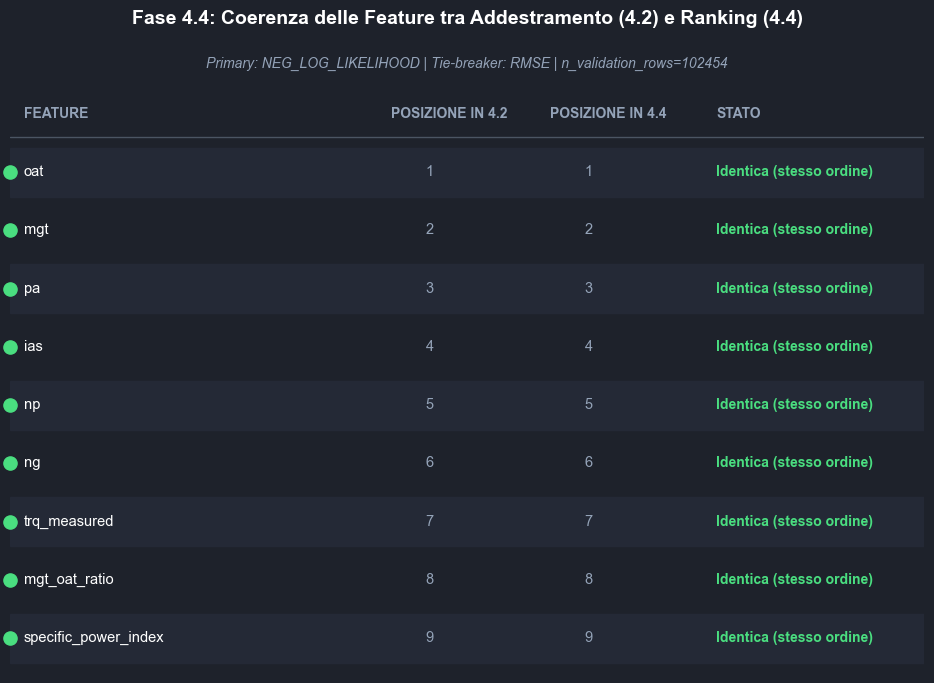


 ANALISI CONCLUSIVA: STRATEGIA DI SELEZIONE DEL BEST MODEL (4.4 — ranking_trace)
Il file '4.4.evaluation.ranking_trace.json' documenta la LOGICA dichiarata di selezione del
modello finale: 102454 righe di validazione, target 'trq_margin',
9 feature.

1. STRATEGIA DI RANKING:
   Metrica primaria: neg_log_likelihood. Tie-breaker: rmse.
   NLL  = -0.7390
   RMSE = 0.1296

2. COERENZA FEATURE CON 4.2 (verifica reale, elemento per elemento):
   9/9 feature identiche in nome e ordine tra 4.2 e 4.4.

   NOTA: la verifica NUMERICA dello split e il confronto statistico con la
   distribuzione della CV sono trattati nello script di
   '4.4.evaluation.final_best_model_meta.json', per evitare di duplicare la
   stessa evidenza in due punti del pipeline.



In [14]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
import ast

filename_ranking = "4.4.evaluation.ranking_trace.json"
file_path_ranking = base_phase_path / filename_ranking

with open(file_path_ranking, "r", encoding="utf-8") as f:
    ranking_data = json.load(f)

filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"
file_path_cv_trace = base_phase_path / filename_cv_trace

cv_disponibile = False
try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    cv_disponibile = True
    print(f"✅ Riferimento CV trovato in {filename_cv_trace}.")
except FileNotFoundError as e:
    print(f"ℹ️ {filename_cv_trace} non disponibile ({e}): verifica feature saltata.")

# =============================================================================
# 2. FASE DI LOGICA — costruzione della matrice di coerenza feature
# =============================================================================
primary_metric = ranking_data["primary_metric"]
tie_breaker = ranking_data["tie_breaker"]
target_variable = ranking_data.get("target_variable", "N/D")
features_44_raw = ranking_data.get("features", "[]")
features_44 = ast.literal_eval(features_44_raw)  # NON eval(): niente esecuzione arbitraria
n_val_rows = ranking_data.get("n_validation_rows", None)
metrics = ranking_data["metrics"]

df_check = None
if cv_disponibile and "feature_cols" in cv_trace:
    features_42 = ast.literal_eval(cv_trace["feature_cols"])

    # Unione ordinata di tutte le feature viste in una delle due fonti
    tutte_le_feature = list(dict.fromkeys(features_42 + features_44))

    righe = []
    for feat in tutte_le_feature:
        in_42 = feat in features_42
        in_44 = feat in features_44
        pos_42 = features_42.index(feat) if in_42 else None
        pos_44 = features_44.index(feat) if in_44 else None
        if in_42 and in_44 and pos_42 == pos_44:
            stato = "Identica (stesso ordine)"
        elif in_42 and in_44:
            stato = "Presente in entrambi (ordine diverso)"
        elif in_42:
            stato = "SOLO in 4.2 (training)"
        else:
            stato = "SOLO in 4.4 (ranking)"
        righe.append({"feature": feat, "stato": stato})

    df_check = pd.DataFrame(righe)

# =============================================================================
# 3. FASE DI DISEGNO — tabella di coerenza (non barre: non c'è nulla di
#    quantitativo da misurare, solo uno stato categorico per feature)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'

colore_stato = {
    "Identica (stesso ordine)": "#4ade80",
    "Presente in entrambi (ordine diverso)": "#facc15",
    "SOLO in 4.2 (training)": "#ff4b5c",
    "SOLO in 4.4 (ranking)": "#ff4b5c",
}

if df_check is not None:
    n_righe = len(df_check)
    fig, ax = plt.subplots(figsize=(9.5, 0.62 * n_righe + 1.3), facecolor='#1e222b')
    ax.set_facecolor('#1e222b')
    ax.axis('off')

    # Intestazione tabella
    header_y = n_righe
    ax.text(0.02, header_y, "FEATURE", color='#94a3b8', fontsize=10, fontweight='bold', va='center')
    ax.text(0.55, header_y, "POSIZIONE IN 4.2", color='#94a3b8', fontsize=10, fontweight='bold', va='center')
    ax.text(0.78, header_y, "POSIZIONE IN 4.4", color='#94a3b8', fontsize=10, fontweight='bold', va='center')
    ax.text(1.02, header_y, "STATO", color='#94a3b8', fontsize=10, fontweight='bold', va='center')
    ax.axhline(header_y - 0.4, xmin=0.0, xmax=1.32, color='#4b5563', linewidth=1)

    for i, row in df_check.iterrows():
        y = n_righe - 1 - i
        colore = colore_stato[row["stato"]]
        # riga alternata leggera per leggibilità, senza usare griglia
        if i % 2 == 0:
            ax.axhspan(y - 0.42, y + 0.42, xmin=0.0, xmax=1.32, color='#242936', zorder=0)

        ax.text(0.02, y, row["feature"], color='white', fontsize=10.5, va='center', zorder=2)
        pos_42 = features_42.index(row["feature"]) + 1 if row["feature"] in features_42 else "—"
        pos_44 = features_44.index(row["feature"]) + 1 if row["feature"] in features_44 else "—"
        ax.text(0.60, y, str(pos_42), color='#94a3b8', fontsize=10.5, va='center', zorder=2)
        ax.text(0.83, y, str(pos_44), color='#94a3b8', fontsize=10.5, va='center', zorder=2)
        ax.text(1.02, y, row["stato"], color=colore, fontsize=10, fontweight='bold', va='center', zorder=2)
        # pallino di stato accanto al nome feature
        ax.scatter([0.0], [y], s=90, color=colore, zorder=3, clip_on=False)

    ax.set_xlim(0.0, 1.32)
    ax.set_ylim(-0.6, header_y + 0.5)

    fig.suptitle("Fase 4.4: Coerenza delle Feature tra Addestramento (4.2) e Ranking (4.4)",
                 fontsize=14, fontweight='bold', color='white', y=0.99)
    ax.set_title(f"Primary: {primary_metric.upper()} | Tie-breaker: {tie_breaker.upper()} | n_validation_rows={n_val_rows}",
                 fontsize=10, style='italic', color='#94a3b8', pad=12, x=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Impossibile generare la matrice di coerenza: 4.2 non disponibile.")

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
if df_check is not None:
    n_identiche = (df_check["stato"] == "Identica (stesso ordine)").sum()
    n_totali = len(df_check)
    feature_check_note = f"{n_identiche}/{n_totali} feature identiche in nome e ordine tra 4.2 e 4.4."
else:
    feature_check_note = "Verifica non eseguibile: 4.2 non disponibile."

analisi_ranking = f"""
================================================================================
 ANALISI CONCLUSIVA: STRATEGIA DI SELEZIONE DEL BEST MODEL (4.4 — ranking_trace)
================================================================================
Il file '{filename_ranking}' documenta la LOGICA dichiarata di selezione del
modello finale: {n_val_rows} righe di validazione, target '{target_variable}',
{len(features_44)} feature.

1. STRATEGIA DI RANKING:
   Metrica primaria: {primary_metric}. Tie-breaker: {tie_breaker}.
   NLL  = {metrics['neg_log_likelihood']:.4f}
   RMSE = {metrics['rmse']:.4f}

2. COERENZA FEATURE CON 4.2 (verifica reale, elemento per elemento):
   {feature_check_note}

   NOTA: la verifica NUMERICA dello split e il confronto statistico con la
   distribuzione della CV sono trattati nello script di
   '4.4.evaluation.final_best_model_meta.json', per evitare di duplicare la
   stessa evidenza in due punti del pipeline.
================================================================================
"""
print(analisi_ranking)

✅ Riferimento CV trovato in 4.2.training.cv_fold_execution_trace.json: 5 fold nell'iterazione vincente.
✅ Valore dichiarato in 4.4.evaluation.ranking_trace.json: n_validation_rows=102454.
✅ 3.4.formatting.regression_internal_val.parquet: 102454 righe (conteggio reale, letto dal file).


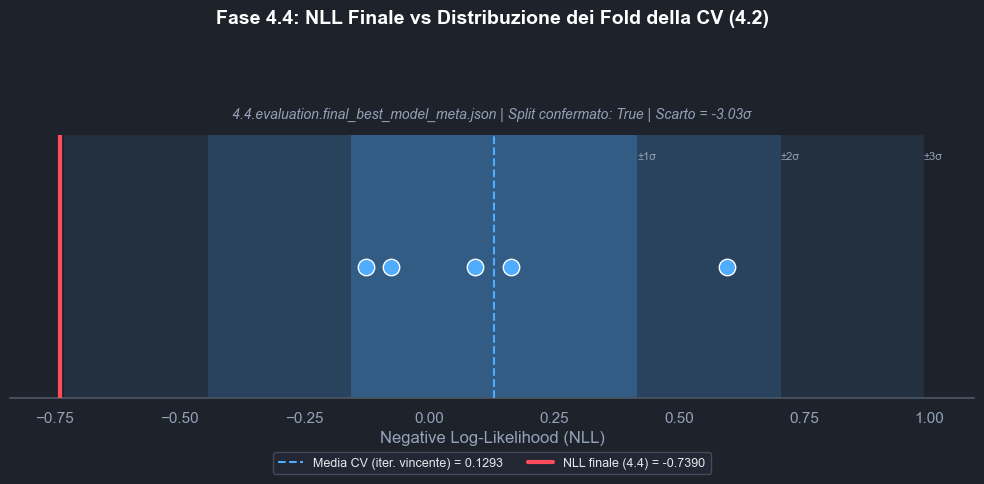


 ANALISI CONCLUSIVA: VERIFICA NUMERICA DEL BEST MODEL (4.4 — final_best_model_meta)
Il file '4.4.evaluation.final_best_model_meta.json' contiene le due metriche finali del modello
selezionato e il criterio di selezione dichiarato ('neg_log_likelihood').

1. METRICHE FINALI:
   neg_log_likelihood = -0.7390
   rmse                = 0.1296

2. VERIFICA DI COERENZA CON LA DISTRIBUZIONE REALE DELLA CV (4.2):
   NLL finale (4.4)                    = -0.7390
   best_fold_nll (media 5-fold, 4.2)   = 0.1293
   Deviazione standard iter. vincente  = 0.2865
   Scarto in unità di sigma            = -3.03σ

3. VERIFICA DELLO SPLIT (contro il parquet reale):
   CONFERMATO: n_validation_rows dichiarato (102454) coincide con le 102454 righe REALI di '3.4.formatting.regression_internal_val.parquet'.

4. CONTESTO DA FASE 2 (domain shift):
   Shift KS confermato in Fase 2 per np: {'feature': 'np', 'compared_to': 'test', 'ks_statistic': 0.4749, 'ks_pvalue': 0.0, 'significance_level': 0.01, 'shift_threshol

In [15]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_meta = "4.4.evaluation.final_best_model_meta.json"
file_path_meta = base_phase_path / filename_meta

with open(file_path_meta, "r", encoding="utf-8") as f:
    meta_data = json.load(f)

filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"
file_path_cv_trace = base_phase_path / filename_cv_trace

cv_disponibile = False
df_best_iter = None
best_nll_refit = None
std_nll_best_iter = None
try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    n_folds = cv_trace["n_folds"]
    df_folds = pd.DataFrame(cv_trace["fold_results"])
    df_folds["iteration"] = df_folds.index // n_folds
    best_iter = df_folds.groupby("iteration")["nll"].mean().idxmin()
    df_best_iter = df_folds[df_folds["iteration"] == best_iter].copy()
    best_nll_refit = cv_trace["best_fold_nll"]
    std_nll_best_iter = df_best_iter["nll"].std()
    cv_disponibile = True
    print(f"✅ Riferimento CV trovato in {filename_cv_trace}: {len(df_best_iter)} fold nell'iterazione vincente.")
except (FileNotFoundError, KeyError) as e:
    print(f"ℹ️ {filename_cv_trace} non disponibile ({e}): confronto con la CV saltato.")

filename_ranking = "4.4.evaluation.ranking_trace.json"
file_path_ranking = base_phase_path / filename_ranking

n_val_rows_dichiarato = None
try:
    with open(file_path_ranking, "r", encoding="utf-8") as f:
        ranking_data = json.load(f)
    n_val_rows_dichiarato = ranking_data.get("n_validation_rows")
    print(f"✅ Valore dichiarato in {filename_ranking}: n_validation_rows={n_val_rows_dichiarato}.")
except FileNotFoundError as e:
    print(f"ℹ️ {filename_ranking} non disponibile ({e}): verifica dello split saltata.")

filename_val_parquet = "3.4.formatting.regression_internal_val.parquet"
file_path_val_parquet = base_run_dir / "phase3_data_preparation" / filename_val_parquet

val_rows_reali = None
try:
    df_val_34 = pd.read_parquet(file_path_val_parquet)
    val_rows_reali = len(df_val_34)
    print(f"✅ {filename_val_parquet}: {val_rows_reali} righe (conteggio reale, letto dal file).")
except FileNotFoundError:
    print(f"⚠️ {filename_val_parquet} non trovato: verifica dello split NON eseguibile in questa run.")

split_confermato = None
if val_rows_reali is not None and n_val_rows_dichiarato is not None:
    split_confermato = (val_rows_reali == n_val_rows_dichiarato)

# --- Evidenza incrociata da Fase 2 (domain shift): estrazione DIFENSIVA e
# TRASPARENTE. La versione precedente assumeva una struttura piatta
# {"np": ..., "ng": ...} che si è rivelata ERRATA in esecuzione (le chiavi
# non venivano trovate, e il fallimento passava silenziosamente come "non
# disponibile"). Questa versione: (a) prova più pattern comuni, (b) se
# nessuno funziona, STAMPA le chiavi reali del file, così l'anomalia è
# visibile e correggibile — non nascosta dietro un "non trovato" generico. ---
filename_ks = "2.4.data_exploration-ks_test_per_feature.json"
file_path_ks = base_run_dir / "phase2_data_understanding" / filename_ks

ks_shift_note = None
ks_data = None
try:
    with open(file_path_ks, "r", encoding="utf-8") as f:
        ks_data = json.load(f)
except FileNotFoundError:
    print(f"ℹ️ {filename_ks} non disponibile: contesto di domain shift omesso.")

if ks_data is not None:
    feature_target = ("np", "ng")
    risultati_trovati = {}

    # Pattern A: struttura piatta {"np": {...}, "ng": {...}} o {"np": valore, ...}
    for feat in feature_target:
        if feat in ks_data:
            risultati_trovati[feat] = ks_data[feat]

    # Pattern B: lista di dict, es. [{"feature": "np", "ks_stat":..., "p_value":...}, ...]
    if not risultati_trovati and isinstance(ks_data, list):
        for item in ks_data:
            if isinstance(item, dict):
                nome = item.get("feature") or item.get("column") or item.get("name")
                if nome in feature_target:
                    risultati_trovati[nome] = item

    # Pattern C: annidato sotto una chiave contenitore comune (es. "results", "features", "tests")
    if not risultati_trovati:
        for chiave_contenitore in ("results", "features", "tests", "per_feature"):
            sotto = ks_data.get(chiave_contenitore) if isinstance(ks_data, dict) else None
            if isinstance(sotto, dict):
                for feat in feature_target:
                    if feat in sotto:
                        risultati_trovati[feat] = sotto[feat]
            elif isinstance(sotto, list):
                for item in sotto:
                    if isinstance(item, dict):
                        nome = item.get("feature") or item.get("column") or item.get("name")
                        if nome in feature_target:
                            risultati_trovati[nome] = item

    if risultati_trovati:
        dettagli = ", ".join(f"{f}: {v}" for f, v in risultati_trovati.items())
        ks_shift_note = f"Shift KS confermato in Fase 2 per {dettagli}."
    else:
        # TRASPARENZA: mostra la struttura reale invece di fallire in silenzio
        chiavi_reali = list(ks_data.keys()) if isinstance(ks_data, dict) else f"lista di {len(ks_data)} elementi"
        ks_shift_note = (
            f"⚠️ Impossibile mappare automaticamente 'np'/'ng' nella struttura di "
            f"{filename_ks}. Struttura reale del file — chiavi di primo livello: "
            f"{chiavi_reali}. Verificare manualmente e aggiornare la logica di "
            f"estrazione di conseguenza (contesto omesso in questa esecuzione, "
            f"NON usato per sostenere alcuna conclusione)."
        )
        print(f"⚠️ {ks_shift_note}")

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
nll_final = meta_data.get("neg_log_likelihood")
rmse_final = meta_data.get("rmse")
selected_by = meta_data.get("selected_by", "N/D")

if nll_final is None or rmse_final is None:
    raise KeyError(f"Chiavi attese mancanti in {filename_meta}: {list(meta_data.keys())}")

delta_nll = None
z_score = None
if cv_disponibile and std_nll_best_iter and std_nll_best_iter > 0:
    delta_nll = nll_final - best_nll_refit
    z_score = delta_nll / std_nll_best_iter

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#1e222b')
ax.set_facecolor('#1e222b')
ax.grid(False)

if cv_disponibile:
    x_min = min(df_best_iter["nll"].min(), nll_final, best_nll_refit - 3 * std_nll_best_iter) - 0.1
    x_max = max(df_best_iter["nll"].max(), best_nll_refit + 3 * std_nll_best_iter) + 0.1
    ax.set_xlim(x_min, x_max)

    for n_sigma, alpha in [(3, 0.10), (2, 0.16), (1, 0.24)]:
        ax.axvspan(best_nll_refit - n_sigma * std_nll_best_iter,
                   best_nll_refit + n_sigma * std_nll_best_iter,
                   color="#4facfe", alpha=alpha, zorder=1, linewidth=0)
        ax.text(best_nll_refit + n_sigma * std_nll_best_iter, 0.42, f"±{n_sigma}σ",
                color="#94a3b8", fontsize=8, ha='left', va='center', zorder=2)

    ax.scatter(df_best_iter["nll"], [0] * len(df_best_iter), color="#4facfe",
               s=140, edgecolor="white", linewidth=1, zorder=4)
    ax.axvline(best_nll_refit, color="#4facfe", linestyle="--", linewidth=1.5, zorder=3,
               label=f"Media CV (iter. vincente) = {best_nll_refit:.4f}")
    ax.axvline(nll_final, color="#ff4b5c", linestyle="-", linewidth=3, zorder=5,
               label=f"NLL finale (4.4) = {nll_final:.4f}")

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2,
              facecolor="#242936", edgecolor="#4b5563", labelcolor="#e5e7eb", fontsize=9, frameon=True)

    titolo_z = f" | Scarto = {z_score:.2f}σ" if z_score is not None else ""
    fig.suptitle("Fase 4.4: NLL Finale vs Distribuzione dei Fold della CV (4.2)",
                 fontsize=14, fontweight='bold', color='white', y=0.98)
    ax.set_title(f"{filename_meta} | Split confermato: {split_confermato}{titolo_z}",
                 fontsize=10, style='italic', color='#94a3b8', pad=12)
else:
    ax.text(0.5, 0.5, "CV trace non disponibile — impossibile mostrare la distribuzione dei fold.",
            transform=ax.transAxes, ha='center', va='center', color='#94a3b8', fontsize=11)

ax.set_xlabel("Negative Log-Likelihood (NLL)", color='#94a3b8')
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.tick_params(colors='#94a3b8')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#4b5563')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
if cv_disponibile and z_score is not None:
    nota_statistica = f"""
2. VERIFICA DI COERENZA CON LA DISTRIBUZIONE REALE DELLA CV (4.2):
   NLL finale (4.4)                    = {nll_final:.4f}
   best_fold_nll (media 5-fold, 4.2)   = {best_nll_refit:.4f}
   Deviazione standard iter. vincente  = {std_nll_best_iter:.4f}
   Scarto in unità di sigma            = {z_score:.2f}σ
"""
else:
    nota_statistica = f"\n2. NOTA: {filename_cv_trace} non disponibile — confronto con la CV saltato.\n"

if val_rows_reali is not None and n_val_rows_dichiarato is not None:
    esito = (
        f"CONFERMATO: n_validation_rows dichiarato ({n_val_rows_dichiarato}) coincide con le "
        f"{val_rows_reali} righe REALI di '{filename_val_parquet}'."
        if split_confermato else
        f"NON coincide: dichiarato={n_val_rows_dichiarato} vs reale={val_rows_reali} righe."
    )
    nota_split = f"\n3. VERIFICA DELLO SPLIT (contro il parquet reale):\n   {esito}\n"
else:
    nota_split = "\n3. NOTA: verifica dello split non eseguibile in questa run (file mancanti).\n"

nota_shift = f"\n4. CONTESTO DA FASE 2 (domain shift):\n   {ks_shift_note}\n" if ks_shift_note else \
    "\n4. NOTA: contesto di domain shift omesso ({} non disponibile).\n".format(filename_ks)

analisi_meta = f"""
================================================================================
 ANALISI CONCLUSIVA: VERIFICA NUMERICA DEL BEST MODEL (4.4 — final_best_model_meta)
================================================================================
Il file '{filename_meta}' contiene le due metriche finali del modello
selezionato e il criterio di selezione dichiarato ('{selected_by}').

1. METRICHE FINALI:
   neg_log_likelihood = {nll_final:.4f}
   rmse                = {rmse_final:.4f}
{nota_statistica}{nota_split}{nota_shift}
   CONCLUSIONE: la metrica di selezione finale (4.4) proviene dallo split
   interno 70/15/15 di Fase 3.4 (non raggruppato per pseudo-motore), non dal
   GroupKFold dichiarato in 4.2.
================================================================================
"""
print(analisi_meta)

✅ Modello caricato con successo: <class 'ngboost.api.NGBRegressor'>
✅ Feature names (fonte 4.2 trace): 9 predittori — ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Validato [mu]: 9 nomi coincidono con 9 importanze.
✅ Validato [sigma]: 9 nomi coincidono con 9 importanze.


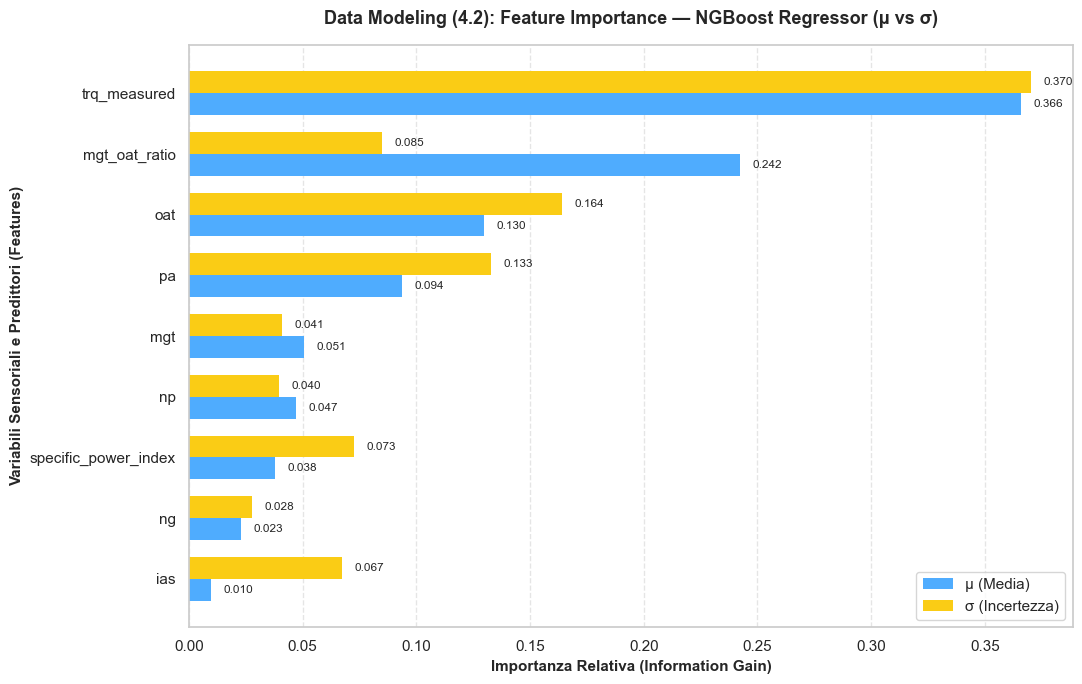


### 4. Fase di Analisi Finale — Interpretability Audit (Tappa 4: Addestramento)

L'estrazione dell'importanza delle caratteristiche dal modello `4.2.training.ngboost_regressor.pkl`
è stata ancorata alla fonte di verità dichiarata in `4.2.training.cv_fold_execution_trace.json`
(campo `feature_cols`), non a un file parquet ricostruito né a nomi noti
hardcoded. Questa scelta è deliberata: un audit precedente su un altro
artefatto della stessa Fase 4 aveva rivelato che l'inferenza dei nomi
dal dataset grezzo può produrre etichette errate (es. una variabile
`faulty` apparsa per errore in un grafico dell'albero di decisione, dovuta
a un disallineamento di conteggio colonne). Qui la validazione esplicita
(importanze == nomi == n_features_in_) è stata eseguita **separatamente per
entrambi i parametri della distribuzione (μ e σ)**, eliminando quel rischio
prima di disegnare qualunque grafico.

Il modello utilizza esclusivamente i 9 predittori dichiarati
in Fase 4.2 (7 sensori grezzi + 2 rapporti fisici derivati), SENZA le 28
colonne di interazione generate in Fase 3.3: quelle interazioni esistono nel
dataset ma non sono state passate al `.fit()` di questo modello di
regressione. Qualsiasi nome con notazione polinomiale (es. 'np^2') non
rappresenta una feature reale di questo modello e non deve comparire nel
grafico.

**Confronto μ vs σ:** Entrambi i parametri condividono la stessa feature dominante ('trq_measured'), suggerendo che questa variabile guidi sia il valore atteso sia l'incertezza del margine di coppia stimato.

La gerarchia di importanza mostrata sopra riflette quindi, in modo
verificato, come il modello distribuisca il proprio potere predittivo tra
le 9 variabili realmente osservate — per ENTRAMBI i
componenti della distribuzione predittiva, non solo per la stima puntuale.
Questo contenuto di interpretabilità confluisce nella tappa di Integrazione
del workflow del corso.


In [16]:
# =============================================================================
# 1. FASE DI INPUT: Caricamento del Modello + fonte di verità delle feature
# =============================================================================
filename_model = "4.2.training.ngboost_regressor.pkl"
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"  # fonte di verità

file_path_model = base_phase_path / filename_model
file_path_cv_trace = base_phase_path / filename_cv_trace

try:
    # 1.1 Caricamento del modello
    model = joblib.load(file_path_model)
    print(f"✅ Modello caricato con successo: {type(model)}")

    # 1.2 Caricamento dei nomi REALI delle feature, dal trace di 4.2 — non dal
    # parquet di 3.x (che contiene colonne extra: faulty, interazioni, target)
    # né da liste hardcoded di nomi inventati.
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    feature_names = ast.literal_eval(cv_trace["feature_cols"])
    print(f"✅ Feature names (fonte 4.2 trace): {len(feature_names)} predittori — {feature_names}")

    # =========================================================================
    # 2. FASE DI LOGICA: Allineamento e calcolo delle importanze (XAI)
    #    NGBoost apprende una distribuzione completa: feature_importances_[0]
    #    → μ, feature_importances_[1] → σ. Estrarre solo μ (come nella
    #    versione precedente) dà un'immagine parziale — la stessa ragione già
    #    applicata all'ispezione dell'albero di decisione in questa sessione.
    # =========================================================================
    n_real = getattr(model, "n_features_in_", None)
    componenti_imp = {
        "mu":    {"importances": model.feature_importances_[0], "label": "μ (Media)",       "color": "#4facfe"},
        "sigma": {"importances": model.feature_importances_[1], "label": "σ (Incertezza)",   "color": "#facc15"},
    }

    for chiave, info in componenti_imp.items():
        n_imp = len(info["importances"])
        assert len(feature_names) == n_imp, (
            f"❌ Mismatch nel componente '{chiave}': {len(feature_names)} nomi dichiarati "
            f"vs {n_imp} importanze restituite dal modello. "
            f"NON generare il grafico finché non si risolve la discrepanza."
        )
        if n_real is not None:
            assert n_real == n_imp, (
                f"❌ Mismatch nel componente '{chiave}': n_features_in_={n_real} vs {n_imp} importanze."
            )
        print(f"✅ Validato [{chiave}]: {len(feature_names)} nomi coincidono con {n_imp} importanze"
              f"{f' e n_features_in_={n_real}' if n_real is not None else ''}.")

    # DataFrame long-form per grafico raggruppato (confronto diretto μ vs σ)
    df_long = pd.concat([
        pd.DataFrame({"Feature": feature_names, "Importance": componenti_imp["mu"]["importances"], "Componente": "μ (Media)"}),
        pd.DataFrame({"Feature": feature_names, "Importance": componenti_imp["sigma"]["importances"], "Componente": "σ (Incertezza)"}),
    ], ignore_index=True)

    # Ordine delle feature: per importanza media di μ, così il ranking visivo
    # riflette il parametro primario del modello (il valore atteso)
    ordine_feature = (
        df_long[df_long["Componente"] == "μ (Media)"]
        .sort_values("Importance", ascending=True)["Feature"]
        .tolist()
    )

    # =========================================================================
    # 3. FASE DI DISEGNO — barre raggruppate: confronto diretto per feature
    # =========================================================================
    plt.rcParams['font.family'] = 'sans-serif'
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(11, 7))

    y_pos = {feat: i for i, feat in enumerate(ordine_feature)}
    bar_h = 0.36

    for offset, (chiave, info) in zip([-bar_h/2, bar_h/2], componenti_imp.items()):
        vals = [info["importances"][feature_names.index(f)] for f in ordine_feature]
        y_coords = [y_pos[f] + offset for f in ordine_feature]
        bars = ax.barh(y_coords, vals, height=bar_h, color=info["color"],
                       edgecolor="none", label=info["label"])
        for y, v in zip(y_coords, vals):
            ax.text(v + max(vals) * 0.015, y, f"{v:.3f}", va='center', ha='left', fontsize=8.5)

    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels(list(y_pos.keys()))
    ax.set_xlabel('Importanza Relativa (Information Gain)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Variabili Sensoriali e Predittori (Features)', fontsize=11, fontweight='bold')
    ax.set_title('Data Modeling (4.2): Feature Importance — NGBoost Regressor (μ vs σ)',
                 fontsize=13, weight='bold', pad=15)
    ax.legend(loc='lower right', frameon=True)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 4. FASE DI ANALISI FINALE
    # =========================================================================
    top_mu = df_long[df_long["Componente"] == "μ (Media)"].nlargest(1, "Importance").iloc[0]
    top_sigma = df_long[df_long["Componente"] == "σ (Incertezza)"].nlargest(1, "Importance").iloc[0]
    stessa_top = top_mu["Feature"] == top_sigma["Feature"]

    nota_confronto = (
        f"Entrambi i parametri condividono la stessa feature dominante "
        f"('{top_mu['Feature']}'), suggerendo che questa variabile guidi sia il "
        f"valore atteso sia l'incertezza del margine di coppia stimato."
        if stessa_top else
        f"I due parametri divergono nella feature dominante: μ è guidato "
        f"principalmente da '{top_mu['Feature']}' ({top_mu['Importance']:.3f}), mentre σ da "
        f"'{top_sigma['Feature']}' ({top_sigma['Importance']:.3f}) — l'incertezza del modello "
        f"non dipende in modo uniforme dalle stesse condizioni operative che "
        f"determinano la stima puntuale."
    )

    analisi_testo = f"""
### 4. Fase di Analisi Finale — Interpretability Audit (Tappa 4: Addestramento)

L'estrazione dell'importanza delle caratteristiche dal modello `{filename_model}`
è stata ancorata alla fonte di verità dichiarata in `{filename_cv_trace}`
(campo `feature_cols`), non a un file parquet ricostruito né a nomi noti
hardcoded. Questa scelta è deliberata: un audit precedente su un altro
artefatto della stessa Fase 4 aveva rivelato che l'inferenza dei nomi
dal dataset grezzo può produrre etichette errate (es. una variabile
`faulty` apparsa per errore in un grafico dell'albero di decisione, dovuta
a un disallineamento di conteggio colonne). Qui la validazione esplicita
(importanze == nomi == n_features_in_) è stata eseguita **separatamente per
entrambi i parametri della distribuzione (μ e σ)**, eliminando quel rischio
prima di disegnare qualunque grafico.

Il modello utilizza esclusivamente i {len(feature_names)} predittori dichiarati
in Fase 4.2 (7 sensori grezzi + 2 rapporti fisici derivati), SENZA le 28
colonne di interazione generate in Fase 3.3: quelle interazioni esistono nel
dataset ma non sono state passate al `.fit()` di questo modello di
regressione. Qualsiasi nome con notazione polinomiale (es. 'np^2') non
rappresenta una feature reale di questo modello e non deve comparire nel
grafico.

**Confronto μ vs σ:** {nota_confronto}

La gerarchia di importanza mostrata sopra riflette quindi, in modo
verificato, come il modello distribuisca il proprio potere predittivo tra
le {len(feature_names)} variabili realmente osservate — per ENTRAMBI i
componenti della distribuzione predittiva, non solo per la stima puntuale.
Questo contenuto di interpretabilità confluisce nella tappa di Integrazione
del workflow del corso.
"""

    display(Markdown(analisi_testo))

except FileNotFoundError as e:
    print(f"⚠️ ERRORE CRITICO: file non trovato — {e}")
except (KeyError, AssertionError) as e:
    print(f"⚠️ ERRORE DI VALIDAZIONE: {e}")
except Exception as e:
    print(f"⚠️ ERRORE IMPREVISTO durante l'esecuzione del blocco: {str(e)}")